# Spring 2026 AE-442 Project 1


# Precession of the perihelion

Kaoutar Ammara <br>
Department of Aerospace Engineering <br>
Izmir University of Economics <br> 

Based on material by Fabrizio Pinto (fabriziopinto2013@gmail.com) <br>
Licensed under CC BY 4.0

Last revised on: 20 May 2026 

<span style='color:red'>  **This is ver. 1.0.1 of this document. Any needed updates will appear as separate, follow-up versions.**</span> 

<div class="alert alert-block alert-info">
<span style='color:black'>  "Precession of the perihelion" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

 <div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 

In [13]:
(*This is needed only for LaTeX output generation, wherever MaTeX instructions are found*)
(*For MaTeX installation information go to: https://github.com/szhorvat/MaTeX#revision-history *)
(* see also: https://zenodo.org/records/7050091 *)
(*If no MaTeX is installed, this notebook can be run by just not using MaTeX instructions*)
<<MaTeX`

Get::noopen: Cannot open MaTeX`.

$Failed

## <a class="anchor" id="Table_of_Contents"></a> Table of Contents 

[Abstract](#Abstract) 

[1. Constants and useful parameters](#1_Constants_and_useful_parameters)

[2. Introduction](#2_Introduction)

[3. Classical Newtonian $2$-body problem](#3_Classical_Newtonian_2BP)   

&emsp; [3.1 Radial coordinate and period of revolution](#3.1_Radial_coordinate) 

&emsp; [3.2 Angular coordinate](#3.2_Angular_coordinate) 

&emsp; [3.3 Trajectory](#3.3_Trajectory) 

&emsp; [3.4 Comparison with the 2-body problem analytical solution](#3.4_Comparison_analytical_solution) 

[4. Numerical perihelion precession ](#4._Numerical_perihelion_precession) 

[5. Nonrelativistic contribution to Mercury's perihelion precession](#5._Nonrelativistic_perihelion_precession)   

[5.1 Perihelion precession due to planetary perturbations](#5.1_Perihelion_precession)

[6. General relativity: Precession of the perihelion](#6._General_relativity)   

[7. Total precession](#7._Total_precession)   

[8. Questions](#8._Questions) 

[References](#References) 

[ChangeLog](#ChangeLog)  



## <a class="anchor" id="Abstract"></a> Abstract 

[Back to Table of Contents](#Table_of_Contents)

The precession of the perihelion is analyzed numerically, $\dots$


## <a class="anchor" id="1_Constants_and_useful_parameters"></a> 1. Constants and useful parameters

[Back to Table of Contents](#Table_of_Contents)  

$$
k_\odot \equiv G M_\odot
$$

Only SI units are used:  


In [30]:
Ggrav = 6.67408 10^(-11);
cLight = 2.99792458 10^8 ;
kSun = 1.32712440041279419 10^(20); 

SiderealYr = 365.256363004 86400 

7
3.15581 10

## <a class="anchor" id="2_Introduction"></a>  2. Introduction 

[Back to Table of Contents](#Table_of_Contents) 

In this Jupyter Notebook $\dots$ 



Let us choose an object orbiting the Sun. For instance, for Mercury, perihelion and aphelion are $r_p=46.00\times 10^6$ km and $r_a=69.82\times 10^6$ km, respectively. That yields the semimajor axis, $a$, and the eccentricity, $e$: 

$$
a = \textstyle{1\over 2}(r_a+r_p)\, ,
$$

$$
e = {r_a - r_p\over r_a + r_p}\, ,
$$

$$
T =   {2 \pi\over \sqrt{GM}} a^{3/2}\, .
$$

In [38]:
SemiMajor[ra_,rp_] = (1/2)(ra+rp) ;
Eccentricity[ra_,rp_] = (ra-rp)/(ra+rp) ;

PeriodRev[ra_,rp_] = (2 Pi/Sqrt[kSun]) ((SemiMajor[ra,rp])^(3/2)) ; 

## <a class="anchor" id="3_Classical_Newtonian_2BP"></a>  3. Classical Newtonian $2$-body problem 

[Back to Table of Contents](#Table_of_Contents) 

We can now calculate the specific angular momentum, $\ell$, and the initially speed of the object assuming, exclusively for convenience, an initial position at aphelion:

$$
\ell = {1\over m}|{\mathbf{r}}\times {\mathbf{p}} | = \sqrt{k_\odot a (1-e^2)} = v_{t,0}\, r_{a}\, . \,\,\,\,\, \,\,\,\,\,    (3)
$$

In [49]:
SpecAngMomenIn [ra_,rp_] = Sqrt[kSun SemiMajor[ra,rp] (1-(Eccentricity[ra,rp])^2) ];
vt0In[ra_,rp_] = (SpecAngMomenIn [ra,rp])/ra ; 

In [51]:
vt0In[69.82 10^9, 46 10^9]

38856.9

Let us set these values as your initial conditions:

In [56]:
r0 = 69.82 10^9 ;
vt0 = vt0In[69.82 10^9, 46 10^9]

38856.9

Let us set final integration time is set so as to complete at least one revolution (by trial and error or Kepler's third Law). 

In [62]:
PeriodRev[69.82 10^9, 46 10^9]

6
7.60071 10

In fact, in order to obtain the precession per century in following sections, we shall integrate the equations of motion over one century: 

In [67]:
tfin = 100 SiderealYr

9
3.15581 10

## <a class="anchor" id="3.1_Radial_coordinate"></a>  3.1 Radial coordinate and period of revolution

[Back to Table of Contents](#Table_of_Contents) 

We can now integrate the Newtonian $2$-body problem radial coordinate differential equation numerically (Kittel 1963, p. 281):

$$
\ddot{r} = {\ell^2\over r^3} - {k_\odot\over r^2}\, .
$$

9
{68.875, {{r -> InterpolatingFunction[{{0., 3.15581 10 }}, <>]}}}
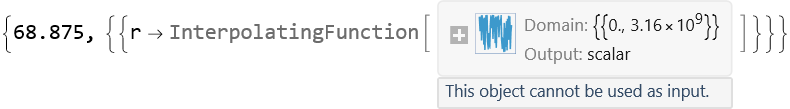

In [72]:
Timing[SolKeplerRad = NDSolve[{r''[t] == (SpecAngMomenIn [69.82 10^9, 46 10^9])^2 (1/(r[t])^3) - (kSun/(r[t])^2) ,r[0]==r0,r'[0]==+0.},r,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [73]:
% [[1]]

68.875

The finite-difference solution for $r(t)$ allows us to define interpolating functions for that quantity, as well as for $\dot{r}(t)$, $\dot{\theta}(t)$, and $v_t(t)$: 

In [78]:
rSol[t_] = Evaluate[r[t] /. SolKeplerRad][[1]];
rDotSol[t_] = Evaluate[r'[t] /. SolKeplerRad][[1]] ; 
ThetaAngDot[t_] = (SpecAngMomenIn[69.82 10^9, 46 10^9])(1/(rSol[t])^2) ;
vtSol[t_] = ThetaAngDot[t]rSol[t] ;

It is useful to obtain plots of these functions (the plots below show the very end of the integration time interval as it would be impractical to the solution over one century):

-Graphics-
-Graphics-
-Graphics-
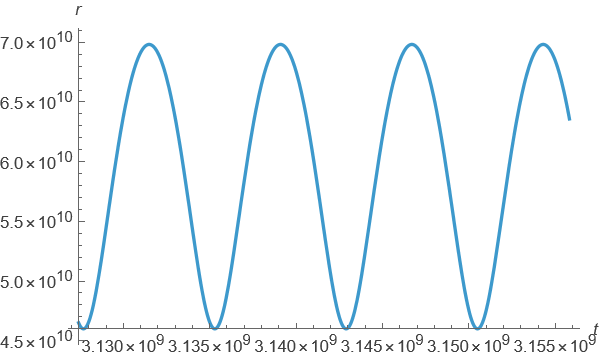
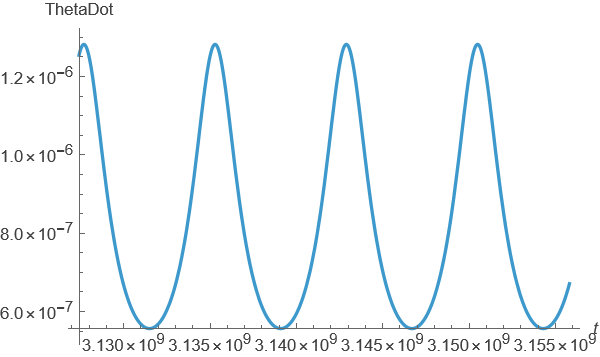
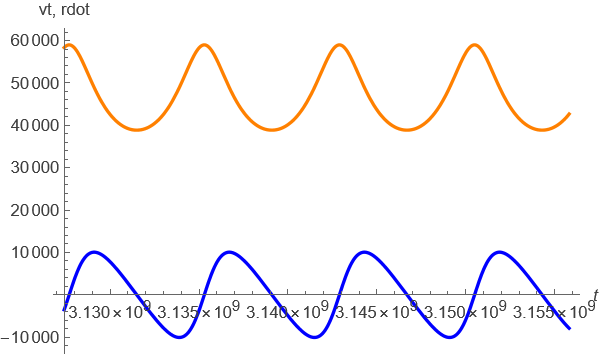

In [86]:
PLOT1 = Plot[rSol[t], {t, 0.991 tfin, tfin}, PlotRange -> All, AxesLabel -> {t, r}]
  
PLOT1B = Plot[ThetaAngDot[t], {t, 0.991 tfin, tfin}, PlotRange -> All, AxesLabel -> {t, ThetaDot}]

PLOT1C = Plot[rDotSol[t], {t, 0.991 tfin, tfin}, PlotRange -> All, PlotStyle -> Blue, AxesLabel -> {t, "vt, rdot"}];
PLOT1D = Plot[vtSol[t], {t, 0.991 tfin, tfin}, PlotRange -> All, 
   PlotStyle -> Orange];
Show[PLOT1C, PLOT1D]
  
  

If we now restrict ourselves to the very last orbit of Mercury in one century, we can find the time of last passage through aphelion:

-Graphics-
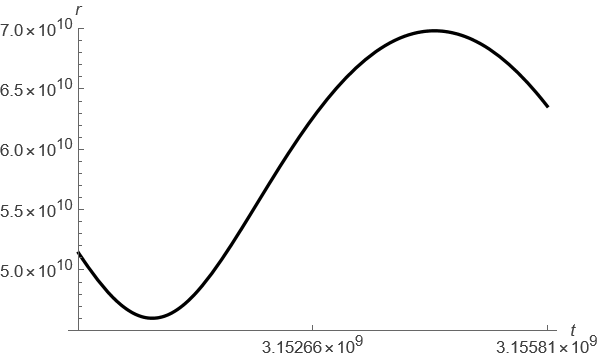

In [98]:
PLOT1B = Plot[rSol[t], {t, 0.998 tfin,  tfin}, PlotRange -> {45 10^9, 70 10^9}, AxesLabel -> {t, r}, PlotStyle->Black, Ticks->{{0.999 tfin,  tfin}, Automatic}]

In [99]:
Export["D:\\AE-442\\Project1\\figures\\rSolPLOT1B.pdf",PLOT1B] 

D:\AE-442\Project1\figures\rSolPLOT1B.pdf

The strategy to determine the time at which Mercury passes through aphelion for the last time, $t_{\mathrm{fin,\, aph}}$, is by instructing Mathematica to locate the maximum in the function $r(t)$:

In [104]:
PeriodRevNum = FindMaximum[rSol[t], {t,0.998 tfin, tfin} ][[2,1,2]] 
PeriodRevNumDays = FindMaximum[rSol[t], {t,0.998 tfin, tfin} ][[2,1,2]] /86400 

9
3.1467 10
36420.1

This time is obviously very close to the final time chosen above:

In [110]:
tfin

9
3.15581 10

## <a class="anchor" id="3.2_Radial_coordinate"></a>  3.2 Angular coordinate

[Back to Table of Contents](#Table_of_Contents) 


The differential equation for the angular coordinate is (Kittel 1963, p. 281):

$$
\dot{\theta} = {\ell\over r^2}\, .
$$

9
{1.15625, {{ThetaAng -> InterpolatingFunction[{{0., 3.15581 10 }}, <>]}}}
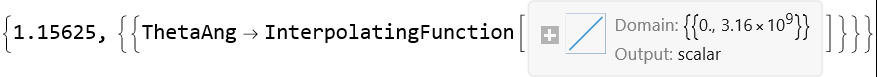

In [115]:
Timing[SolKeplerAng =NDSolve[{ThetaAng'[t] == (SpecAngMomenIn [69.82 10^9, 46 10^9])(1/(rSol[t])^2) ,ThetaAng[0]==0},ThetaAng,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [116]:
% [[1]]

1.15625

Again the finite-difference solution for $\theta(t)$ allows us to define the interpolating function for that quantity: 

9
InterpolatingFunction[{{0., 3.15581 10 }}, <>][t]
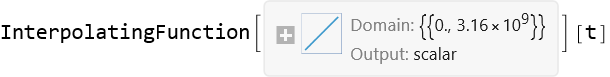

In [121]:
ThetaAngSol[t_] = Evaluate[ThetaAng[t] /. SolKeplerAng][[1]]

The plot is as follows:

-Graphics-
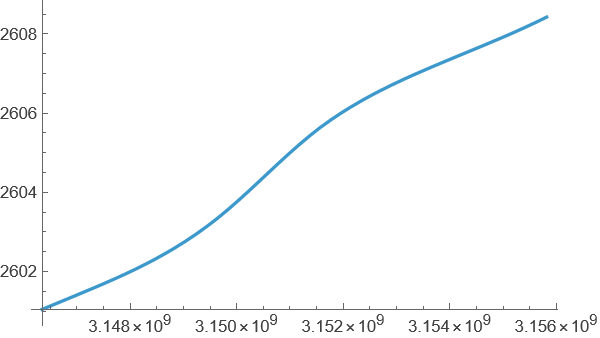

In [126]:
PLOT2 = Plot[ThetaAngSol[t], {t, 0.997 tfin, tfin}, PlotRange -> All, PlotRange -> {0, 2 Pi}]

## <a class="anchor" id="3.3_Trajectory"></a>  3.3 Trajectory

[Back to Table of Contents](#Table_of_Contents) 

In order to draw the trajectory, we switch to Cartesian coordinates:


In [131]:
xSol[t_] = rSol[t] Cos[ThetaAngSol[t]];
ySol[t_] = rSol[t] Sin[ThetaAngSol[t]];

These coordinates, as a function of time, are as follows:

-Graphics-
-Graphics-
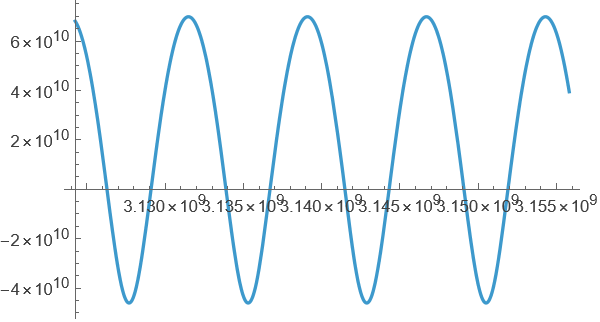
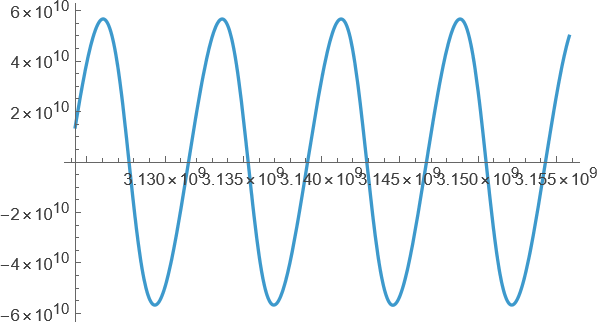

In [137]:
PLOT3 = Plot[xSol[t], {t, 0.990 tfin, tfin}, PlotRange -> All, PlotRange -> All]
PLOT3 = Plot[ySol[t], {t, 0.990 tfin, tfin}, PlotRange -> All, 
  PlotRange -> All]

We can now create a parametric plot, ($\theta (t)$, $r (t)$), in *Cartesian* coordinates (notice that the angular coordinate is plotted in arcseconds). This plot will be employed later to visualize the precession of the perihelion:

-Graphics-
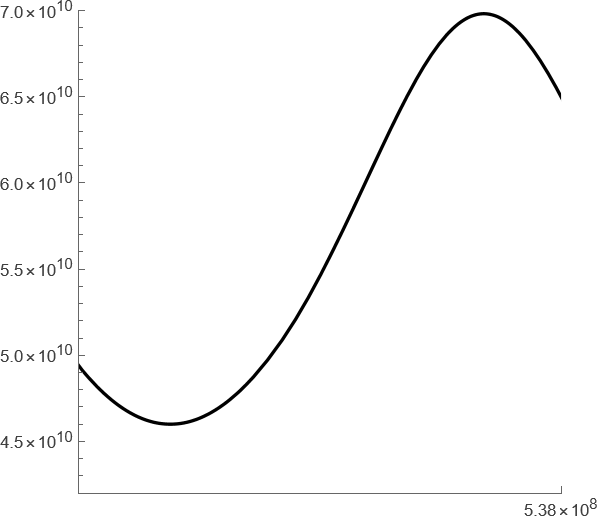

In [143]:
PLOT1E = ParametricPlot[{ThetaAngSol[t] (180/Pi) (3600), rSol[t]}, {t,
    0.998 tfin, tfin}, Ticks ->{{ 1.076 10^9/4, 1.076 10^9/2}, Automatic}, 
  PlotRange -> {{1.074 10^9/2, 1.076 10^9/2}, {42 10^9, 70 10^9}}, AspectRatio -> 1, PlotStyle->Black]

Finally, we can produce the *polar* parametric plot of the two Cartesian coordinates to visualize the trajectory:  

-Graphics-
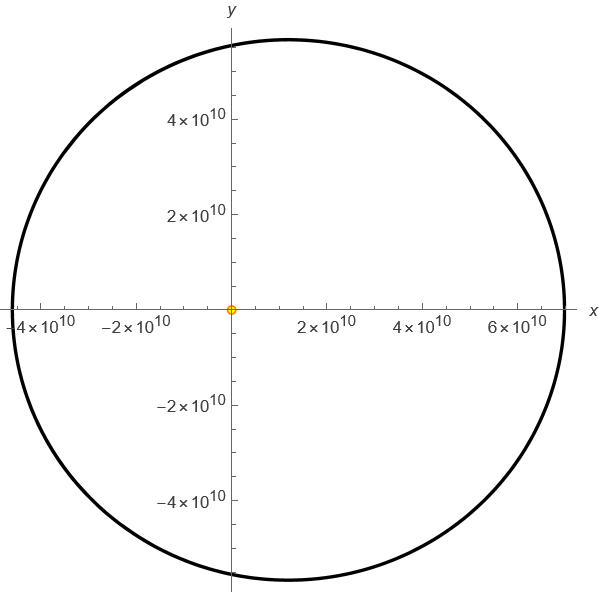

In [148]:
PLOTMercuryTraj = 
  ParametricPlot[{xSol[t], ySol[t]}, {t, 0, 0.01 tfin}, Axes -> True, 
   AxesLabel -> {x, y}, PlotStyle -> Black];

PLOTSunEdge = 
  Graphics[{Orange, Thick, Circle[{0, 0}, 6.96 10^8]} , Axes -> True, 
   AxesLabel -> {x, y}];
PLOTSunDisk = Graphics[{Yellow, Disk[{0, 0}, 6.96 10^8]} ];
PLOTSun = Show[PLOTSunEdge, PLOTSunDisk];

PlotNumerAll  = Show[PLOTSun, PLOTMercuryTraj]

#### Export – Mercury trajectory (Section 3.3)

In [157]:
(* Export the Mercury trajectory plot *)
Export["D:\\AE-442\\Project1\\figures\\mercury-trajectory.pdf", PlotNumerAll];
Print["Exported: figures/mercury_trajectory.pdf"]

Exported: figures/mercury_trajectory.pdf


## <a class="anchor" id="3.4_Comparison_analytical_solution"></a>  3.4 Comparison with the 2-body problem analytical solution

[Back to Table of Contents](#Table_of_Contents) 

The analytical solution for the trajectory, $r=r(\theta)$ can be written by computing the conserved quantities from the initial conditions (assuming an initial position at either peri- or apoapsis), that is, the specific energy, $\cal{E}$, and the magnitude of the specific angular momentum, $\ell$. From the theory of the $2$-body problem, we obtain the eccentricity, $e$, the semimajor axis, $a$, and the semilatus rectum, $p$ (as shown in Bate, Ch. 1, and Kittel, Ch. 9). 

The trajectory equation reads, assuming $r(\theta=0) = r_a$:

$$
r (\theta) = {a (1-e^2)\over 1 -e \cos\theta}
$$ 

In [164]:
SemiMajor[ra_,rp_] = (1/2)(ra+rp) ;
Eccentricity[ra_,rp_] = (ra-rp)/(ra+rp) ;

2
               (ra - rp)
(ra + rp) (1 - ----------)
                        2
               (ra + rp)
--------------------------
            2
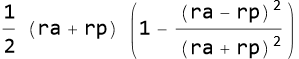

In [166]:
SemiLatus[ra_,rp_] = SemiMajor[ra,rp] (1-(Eccentricity[ra,rp])^2)

In [167]:
SemiLatus[69.82 10^9, 46 10^9]

10
5.54605 10

Therefore, the analytical equation for the trajectory reads:

2
                   (ra - rp)
    (ra + rp) (1 - ----------)
                            2
                   (ra + rp)
----------------------------------
       (ra - rp) Cos[ThetaAnalyt]
2 (1 - --------------------------)
                ra + rp
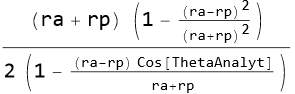

In [172]:
rAnalyt[ra_,rp_, ThetaAnalyt_] = SemiLatus[ra,rp]/(1 - Eccentricity[ra,rp] Cos[ThetaAnalyt]) 

10
6.982 10
                  10
        5.54605 10
-----------------------------
1 - 0.205664 Cos[ThetaAnalyt]
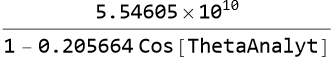

In [173]:
rAnalyt[69.82 10^9, 46 10^9,0]
rAnalyt[69.82 10^9, 46 10^9,ThetaAnalyt] 

#### Export – Analytical orbit formula (Section 3.4)

In [179]:
xAnalyt[ra_,rp_, ThetaAnalyt_] = rAnalyt[ra, rp, ThetaAnalyt] Cos[ThetaAnalyt];
yAnalyt[ra_,rp_, ThetaAnalyt_] = rAnalyt[ra, rp, ThetaAnalyt] Sin[ThetaAnalyt]; 

Exported: figures/trajectory_comparison.pdf


-Graphics-
-Graphics-
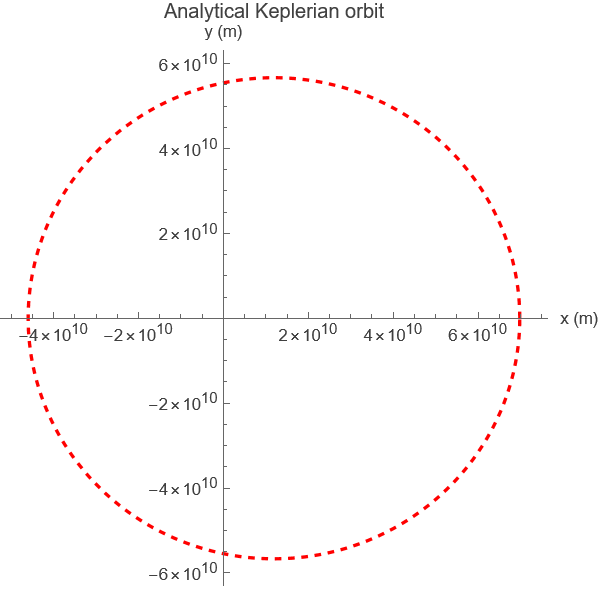
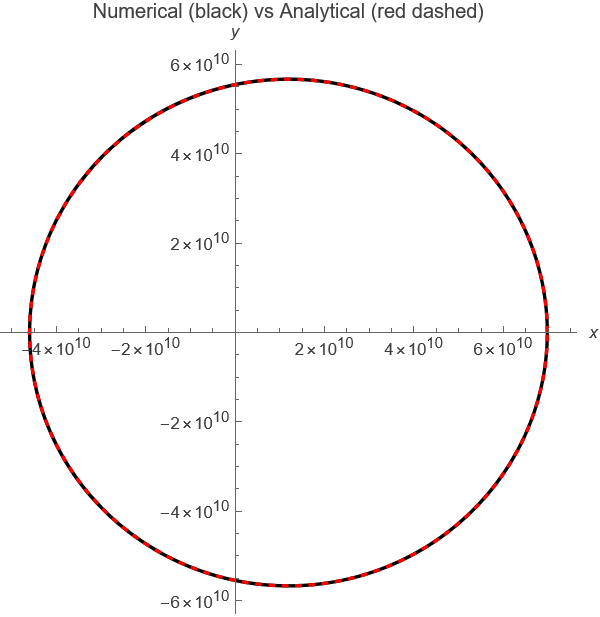

In [181]:
(* Build analytical vs numerical comparison plot *)
PLOTAnalytTraj = ParametricPlot[
  {xAnalyt[69.82 10^9, 46 10^9, theta], yAnalyt[69.82 10^9, 46 10^9, theta]},
  {theta, 0, 2 Pi},
  PlotStyle -> {Red, Dashed},
  AxesLabel -> {"x (m)", "y (m)"},
  PlotLabel -> "Analytical Keplerian orbit"]

PLOTCompare = Show[
  PLOTMercuryTraj,
  PLOTAnalytTraj,
  PlotLabel -> "Numerical (black) vs Analytical (red dashed)",
  PlotRange -> All]

Export["D:\\AE-442\\Project1\\figures\\trajectory-comparison.pdf", PLOTCompare];
Print["Exported: figures/trajectory_comparison.pdf"]

By again transforming from polar to Cartesian coordinates and creating a parametric plot: 

-Graphics-
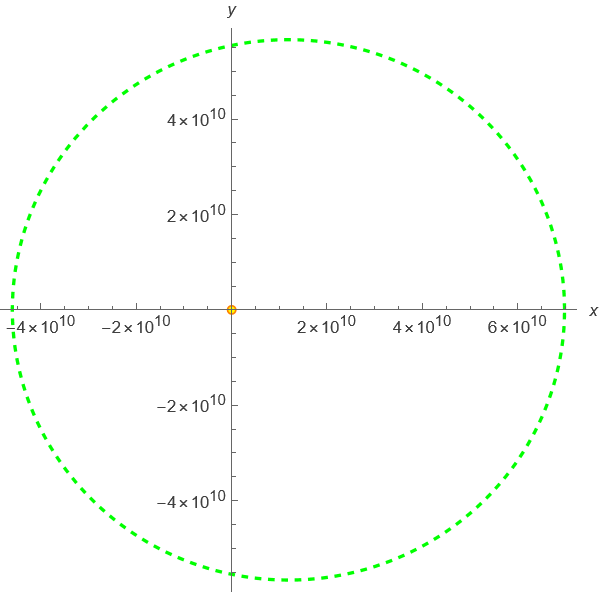

In [190]:
PLOTMercuryTrajAnalyt = ParametricPlot[{xAnalyt[69.82 10^9, 46 10^9,ThetaAnalyt],yAnalyt[69.82 10^9, 46 10^9,ThetaAnalyt]},{ThetaAnalyt,0,2 Pi},Axes->True,AxesLabel->{x,y},PlotStyle->{Dashed,Green}];

PlotAnalytAll  =Show[PLOTSun,PLOTMercuryTrajAnalyt]

A first comparison of the numerical and of the analytical results can be carried out visually by superimposing the results:

-Graphics-
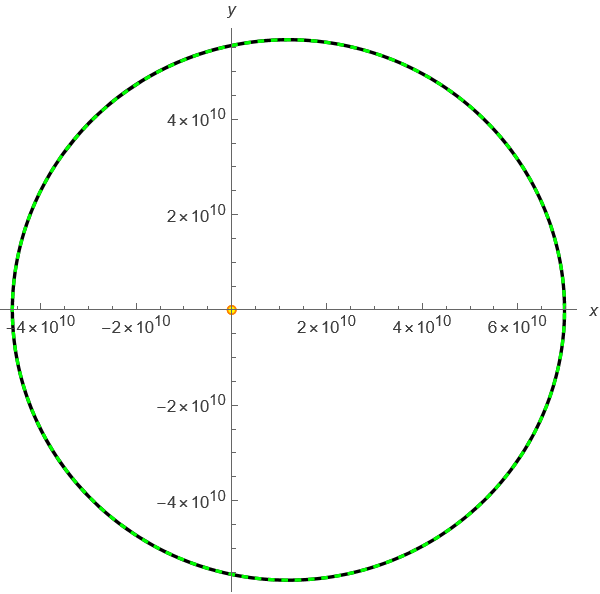

In [196]:
PLOTNumAnalytc = Show[PlotNumerAll,PlotAnalytAll] 

In [197]:
(*the location of I/O files must be changed as needed*)
Export["D:\\AE-442\\Project1\\figures\\PLOTNumAnalytc.pdf", PLOTNumAnalytc] 

D:\AE-442\Project1\figures\PLOTNumAnalytc.pdf

The numerical errors in the long term behavior of the integration are clearly visible:

-Graphics-
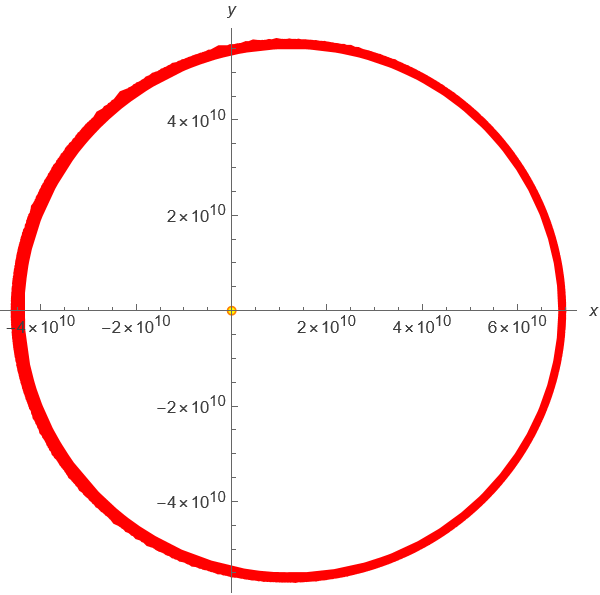

In [203]:
PLOTMercuryTraj2 = 
  ParametricPlot[{xSol[t], ySol[t]}, {t, 0.0 tfin, 0.51 tfin}, Axes -> True, 
   AxesLabel -> {x, y}, PlotStyle -> Red];

PLOTSunEdge = 
  Graphics[{Orange, Thick, Circle[{0, 0}, 6.96 10^8]} , Axes -> True, 
   AxesLabel -> {x, y}];
PLOTSunDisk = Graphics[{Yellow, Disk[{0, 0}, 6.96 10^8]} ];
PLOTSun = Show[PLOTSunEdge, PLOTSunDisk];

PlotNumerAll2  = Show[PLOTSun, PLOTMercuryTraj2]

-Graphics-
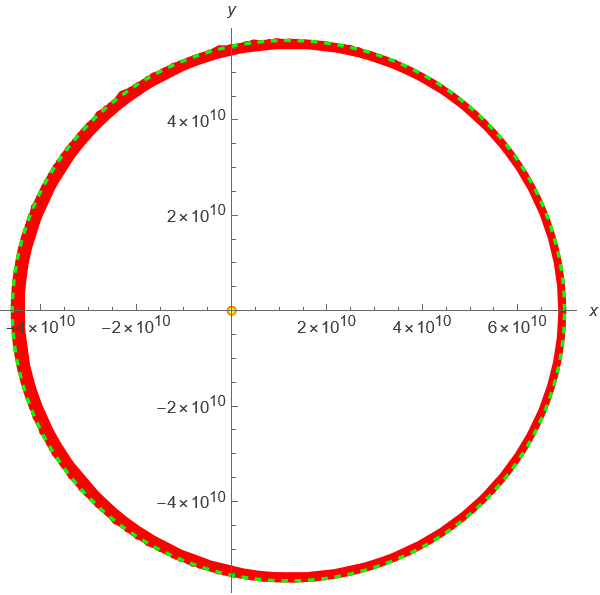

In [208]:
PLOTNumAnalytc2 = Show[PlotNumerAll2,PlotAnalytAll] 

We can conclude this Section by computing the period of revolution from the theory of the $2$-body problem seen above:

In [213]:
PeriodRev[69.82 10^9, 46 10^9] 
PeriodRev[69.82 10^9, 46 10^9]/(86400)

6
7.60071 10
87.9712

The numerical period can be found by locating the *first* time at which the planet goes through aphelion:

-Graphics-
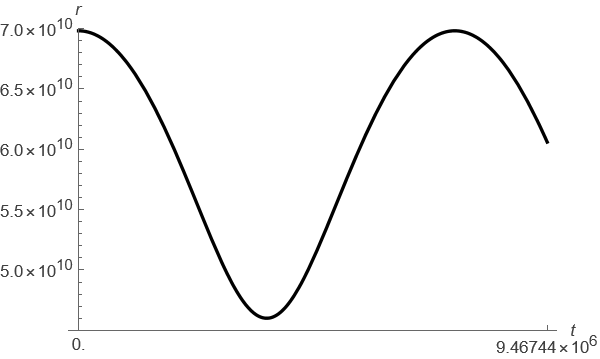

In [219]:
PLOT1C = Plot[rSol[t], {t, 0.0 tfin,  0.003 tfin}, PlotRange -> {45 10^9, 70 10^9}, AxesLabel -> {t, r}, PlotStyle->Black, Ticks->{{0.0 tfin, 0.003  tfin}, Automatic}]

In [220]:
0.002 tfin

6
6.31163 10

In [221]:
PeriodRevNumInit = FindMaximum[rSol[t], {t, 0.002 tfin, 0.003 tfin} ][[2,1,2]] 

6
7.60071 10

We can now use this result to obtain the relative error: 

In [226]:
(PeriodRevNumInit - PeriodRev[69.82 10^9, 46 10^9] )/PeriodRev[69.82 10^9, 46 10^9] 

-13
-4.11091 10

## <a class="anchor" id="4._Numerical_perihelion_precession"></a>  4. Numerical perihelion precession 

[Back to Table of Contents](#Table_of_Contents) 

Due to the process of numerical integration, the perihelion of Mercury is predicted to precess.  This numerical perihelion precession, which has no bearing on the $2$-body problem and it is only connected to numerical integration errors, is here expressed in arcsecs:

In [231]:
ThetaAngSol0 = ThetaAngSol[PeriodRevNum] (180/Pi) (3600) 

8
5.36544 10

#### Export – Numerical perihelion precession baseline (Section 4)

Exported: figures/precession_baseline_table.pdf


Numerical baseline precession (arcsec/century)

          8
5.36544 10
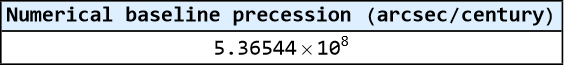

In [236]:
(* Display and export the baseline precession value *)
precBaseline = ThetaAngSol0;
PLOTPrecBaseline = Grid[
  {{Style["Numerical baseline precession (arcsec/century)", Bold]},
   {precBaseline}},
  Frame -> All, Background -> {{}, {LightBlue, White}}]
Export["D:\\AE-442\\Project1\\figures\\precession-baseline-table.pdf", PLOTPrecBaseline];
Print["Exported: figures/precession_baseline_table.pdf"]

The value to be considered is the difference between this value and the value corresponding to the total number of revolutions in one century:

In [245]:
((100 SiderealYr) / PeriodRev[69.82 10^9, 46 10^9] )(2 Pi 180/Pi) (3600) 
ThetaAngSol0 - ((100 SiderealYr) / PeriodRev[69.82 10^9, 46 10^9] )(2 Pi 180/Pi) (3600) 

8
5.38099 10
          6
-1.5549 10

This value is obviously very large compared to any other quantity of physical significance. This value but it will be presumed to a good approximation to be identically affecting all calculations for the same planet over the same period of time. 

## <a class="anchor" id="5._Nonrelativistic_perihelion_precession"></a>  5. Nonrelativistic contribution to Mercury's perihelion precession

[Back to Table of Contents](#Table_of_Contents) 

Here we repeat the same calculation by introducing the force between Mercury and the outer planets, assumed to be spread into "rings of matter," that is, the approach employed by Le Verrier. Following Price and Rush (1979), we shall assume the orbits of the planets to be circular with the following radii (or semimajor axes, $a_i$):

In [255]:
SemiMajor[69.82 10^9, 46 10^9] 

SMAVenus =  1.082 10^(11);
SMAEarth =   1.496 10^(11);
SMAMars =   2.279 10^(11);
SMAJupiter =   7.783 10^(11);
SMASaturn =   14.27 10^(11);

10
5.791 10

Let us now introduce the masses of the planets in terms of the mass of the Earth, $M_\oplus$:

In [265]:
MEarth = 5.9722 10^(24);

MVenus = 0.815 MEarth
MMars = 0.107 MEarth
MJupiter = 317.8 MEarth
MSaturn = 95.16 MEarth

24
4.86734 10
          23
6.39025 10
          27
1.89797 10
          26
5.68315 10

The effective linear densities, $\lambda_i$, of each planet "ring" are:

In [274]:
lambdaVenus = MVenus /(2 Pi SMAVenus )
lambdaEarth = MEarth /(2 Pi SMAEarth )

lambdaMars = MMars /(2 Pi SMAMars)
lambdaJupiter = MJupiter /(2 Pi SMAJupiter)
lambdaSaturn = MSaturn /(2 Pi SMASaturn)

12
7.15954 10
          12
6.35364 10
          11
4.46266 10
          14
3.88116 10
          13
6.33848 10

As discussed in detail in the paper by Price and Rush (1979), the acceleration due to the gravitational force between Mercury and the $i$th ring can be written as:

$$
\ddot{r}_{{\mathrm{Mercury}}, i}= {1\over m_{\mathrm{Mercury}}} F_{{\mathrm{Mercury}}, i} = \pi G \lambda_i {r\over a_i^2 - r^2  }\, .
$$

Therefore the total perturbative radial acceleration due to all the planets is:
$$
\ddot{r}_{\mathrm{Mercury, pert}}= \sum_{i=2}^{5} \ddot{r}_{{\mathrm{Mercury}}, i}\, .
$$

Notice that $\ddot{r}_{{\mathrm{Mercury}}, i} >0$ for every $i$, corresponding to a small "repulsive" radial force away from the Sun.  

We are now ready to again integrate the radial equation of motion numerically, unlike the perturbative calculation presented by Price and Rush (1979). In order to make the effect of the perturbation more manifest, we shall multiply the above acceleration by a factor $P_{\mathrm{factor}}=10^2$. We shall divide the precession effect by the same factor at the end of the calculation, in the assumption the effect is linear:

In [287]:
PFactor = 10^2;

9
{62.9844, {{r -> InterpolatingFunction[{{0., 3.15581 10 }}, <>]}}}
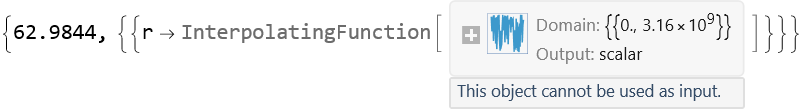

In [288]:
Timing[SolKeplerPertRad =NDSolve[{r''[t] == (SpecAngMomenIn [69.82 10^9, 46 10^9])^2 (1/(r[t])^3) - (kSun/(r[t])^2) +(PFactor) ( (Ggrav  Pi lambdaVenus r[t])/(SMAVenus^2 -(r[t])^2 )+(Ggrav  Pi lambdaEarth r[t])/(SMAEarth^2 -(r[t])^2 )+(Ggrav  Pi lambdaMars r[t])/(SMAMars^2 -(r[t])^2 )+(Ggrav  Pi lambdaJupiter r[t])/(SMAJupiter^2 -(r[t])^2 )+(Ggrav  Pi lambdaSaturn  r[t])/(SMASaturn^2 -(r[t])^2 )),r[0]==r0,r'[0]==+0.},r,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [289]:
% [[1]]

62.9844

The processing of this solution proceeds analogously to the case above:  

In [294]:
rPertSol[t_] = Evaluate[r[t] /. SolKeplerPertRad][[1]] ;

rDotPertSol[t_] = Evaluate[r'[t] /. SolKeplerPertRad][[1]] ;

ThetaAngPertDot[t_] = (SpecAngMomenIn [69.82 10^9, 46 10^9]) (1/(rPertSol[t])^2);
vtPertSol[t_] = ThetaAngPertDot[t] rPertSol[t] ;

The angular coordinate proceeds analogously to the unperturbed case, since the perturbative force is radial so that the angular momentum is still conserved:  

9
{0.859375, {{ThetaAng -> InterpolatingFunction[{{0., 3.15581 10 }}, <>]}}}
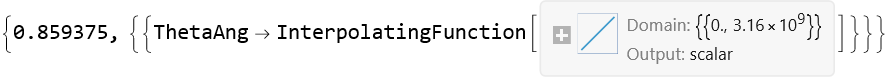

In [302]:
Timing[SolKeplerPertAng = 
 NDSolve[{ThetaAng'[t] == (SpecAngMomenIn [69.82 10^9, 46 10^9]) (1/(rPertSol[t])^2) ,
    ThetaAng[0] == 0}, ThetaAng, {t, 0, tfin}, AccuracyGoal -> 15, 
  PrecisionGoal -> 15, MaxSteps -> \[Infinity], 
  Method -> {"StiffnessSwitching", "NonstiffTest" -> False}]]


In [303]:
%[[1]]

0.859375

9
InterpolatingFunction[{{0., 3.15581 10 }}, <>][t]
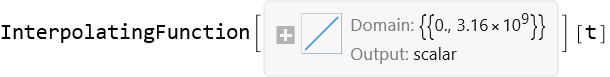

In [304]:
ThetaAngPertSol[t_] = Evaluate[ThetaAng[t] /. SolKeplerPertAng][[1]]

The strategy to determine the period of revolution of Mercury is also the same as above. Here we recall the unpertubed result:

In [309]:
PeriodRevNum = FindMaximum[rSol[t], {t,0.998 tfin, tfin} ][[2,1,2]] 
PeriodRevNumDays = FindMaximum[rSol[t], {t,0.998 tfin, tfin} ][[2,1,2]] /86400 

9
3.1467 10
36420.1

The perturbed result is:

In [315]:
PeriodRevNumPert = FindMaximum[rPertSol[t], {t, 0.998 tfin, tfin} ][[2, 1, 2]] 
PeriodRevNumDaysPert = FindMaximum[rPertSol[t], {t, 0.998 tfin, tfin} ][[2, 1, 2]] /86400 

9
3.14729 10
36427.

The parametric plot, ($\theta (t)$, $r (t)$), in *Cartesian* coordinates, becomes:

-Graphics-
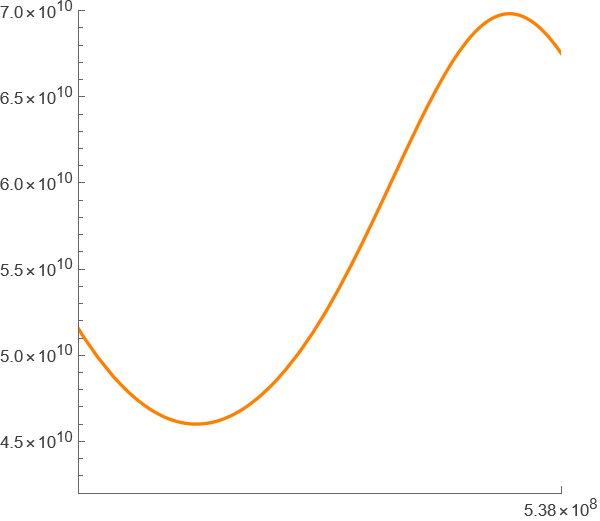

In [321]:
PLOT1G = ParametricPlot[{ThetaAngPertSol[t] (180/Pi) (3600), 
   rPertSol[t]}, {t, 0.998 tfin, tfin}, 
  PlotRange -> {{1.074 10^9/2, 1.076 10^9/2}, {42 10^9, 70 10^9}}, AspectRatio -> 1, 
  PlotStyle -> Orange, Ticks ->{{1.076 10^9/4, 1.076 10^9/2}, Automatic}]

By comparing the unperturbed and perturbed cases: 

-Graphics-
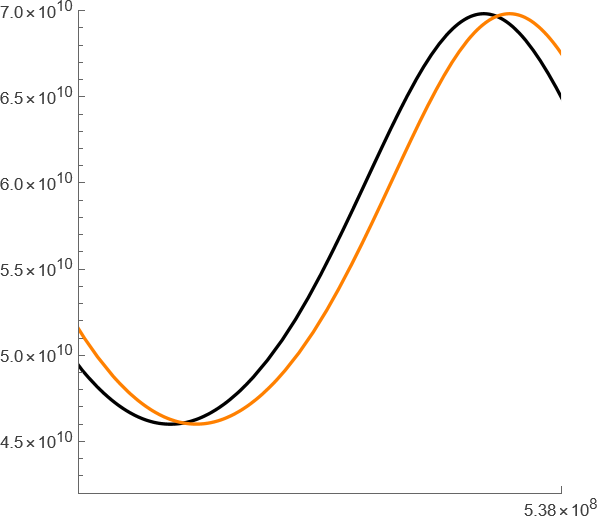

In [326]:
Show[PLOT1E,PLOT1G]

As is apparent, Mercury reaches aphelion out of phase with respect to the unperturbed case, corresponding to a precession of major axis.  

## <a class="anchor" id="5.1_Perihelion_precession"></a>  5.1 Perihelion precession due to planetary perturbations

[Back to Table of Contents](#Table_of_Contents) 

We can now employ the same strategy used to evaluate the numerical precession to compute the total preecession, which will include both the numerical effect and that caused by the perturbations due to all other planets. The true anomaly at the last passage through aphelion is:

In [335]:
ThetaAngSolPert = ThetaAngPertSol[PeriodRevNumPert] (180/Pi) (3600)

8
5.36597 10

We can finally compute the precession of the perihelion of Mercury due to perturbations due to the other planets, including diving by the the magnification factor:  

In [340]:
PerihelionPrecNRel = (ThetaAngSolPert - ThetaAngSol0)/PFactor 

530.722

This result must be compared with that given by Price and Rush (1979) at the their Eq. (21):

$$
\dot{\omega} = 531.9\, {\mathrm{arcsec/century}}\, .
$$

#### Nonrelativistic planetary precession (Section 5)

Planet    Mass (Earth masses)   Semimajor Axis (AU)   λ (kg/m)

                                                                12
Venus     0.815                 0.723262              7.15954 10

                                                                12
Earth     1.                    1.                    6.35364 10

                                                                11
Mars      0.107                 1.524                 4.46266 10

                                                                14
Jupiter   317.8                 5.203                 3.88116 10

                                                                13
Saturn    95.16                 9.537                 6.33848 10
Framed[Non-Relativistic Perihelion Precession                 , 
       Due to planetary perturbations: 530.722 arcsec/century
       Price & Rush (1979) reference:     531.9 arcsec/century
 
>   FrameStyle -> RGBColor[0, 0, 1], Background -> RGBColor[0.87, 0.94, 1]]
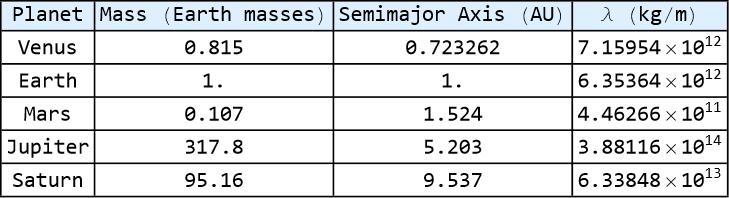
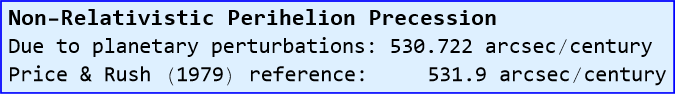

In [349]:
(* Export planet contribution table *)
planetData = {
  {"Planet", "Mass (Earth masses)", "Semimajor Axis (AU)", "\[Lambda] (kg/m)"},
  {"Venus",   0.815,  1.082/1.496, lambdaVenus},
  {"Earth",   1.000,  1.000,       lambdaEarth},
  {"Mars",    0.107,  1.524,       lambdaMars},
  {"Jupiter", 317.8,  5.203,       lambdaJupiter},
  {"Saturn",  95.16,  9.537,       lambdaSaturn}
};

PLOTPlanetTable = Grid[planetData, Frame -> All,
  Background -> {{}, {LightBlue, {White}}},
  Alignment -> Center]

Export["D:\\AE-442\\Project1\\figures\\planet-mass_table.pdf", PLOTPlanetTable];

(* Export the NRel precession result *)
PLOTNRelResult = Framed[
  Column[{
    Style["Non-Relativistic Perihelion Precession", Bold, 14],
    Row[{"Due to planetary perturbations: ", PerihelionPrecNRel, " arcsec/century"}],
    Row[{"Price & Rush (1979) reference:     531.9 arcsec/century"}]
  }], FrameStyle -> Blue, Background -> LightBlue]
Export["D:\\AE-442\\Project1\\figures\\precession-nonrelativistic.pdf", PLOTNRelResult];

## <a class="anchor" id="6._General_relativity"></a>   6. General relativity: Precession of the perihelion

[Back to Table of Contents](#Table_of_Contents)

The general relativistic perihelion precession, produced by Einstein (1915) as the first confirmation of the general relativity theory, is, in radians/revolution, is:

$$
\Delta\phi = 6 \pi {G M_\odot\over c^2(1-e^2)a}\, .
$$

This expression is discussed, for instance, in Landau and Lifshitz (1975), $\S$ 98, and Weinberg (1972) Ch. 8, Sec. 6.  

This yields the following function in arcseconds/revolution:

10
       1.14822 10
--------------------------
                        2
               (ra - rp)
(ra + rp) (1 - ----------)
                        2
               (ra + rp)
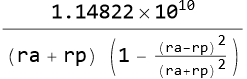

In [364]:
PrecPeriTh[ra_,rp_] = 6 Pi kSun/(cLight^2 SemiMajor[ra,rp](1 - ((Eccentricity[ra,rp])^2))) (180/Pi) 3600 

#### Export – GR precession formula (Section 6)

Exported: figures/precession_GR.pdf


2
Framed[GR Perihelion Precession – Mercury     , FrameStyle -> RGBColor[0, -, 0], 
       Per revolution:  0.103517 arcsec/rev                               3
       Per century:     42.9803 arcsec/century
 
>   Background -> RGBColor[0.88, 1, 0.88]]
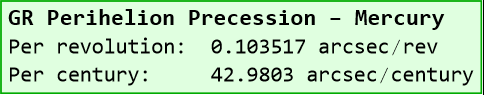

In [369]:
(* Export GR precession per revolution for Mercury *)
grPerRev = PrecPeriTh[69.82 10^9, 46 10^9];
nRevCentury = (100 SiderealYr)/PeriodRev[69.82 10^9, 46 10^9];
grPerCentury = grPerRev nRevCentury;

PLOTGRResult = Framed[
  Column[{
    Style["GR Perihelion Precession – Mercury", Bold, 14],
    Row[{"Per revolution:  ", N[grPerRev, 6], " arcsec/rev"}],
    Row[{"Per century:     ", N[grPerCentury, 6], " arcsec/century"}]
  }], FrameStyle -> Darker[Green], Background -> LightGreen]
Export["D:\\AE-442\\Project1\\figures\\precession-GR.pdf", PLOTGRResult];
Print["Exported: figures/precession_GR.pdf"]

In [376]:
PrecPeriTh[69.82 10^9, 46 10^9] 

0.103517

As  have seen above, Mercury completes the following number of revoutions in one century:

In [381]:
((100 SiderealYr) / PeriodRev[69.82 10^9, 46 10^9] )

415.2

Therefore the analytical (perturbative) value of the general relativistic precession of perihelion is, in arcseconds/century:

In [386]:
PrecPeriTh[69.82 10^9, 46 10^9]  ((100 SiderealYr) / PeriodRev[69.82 10^9, 46 10^9] )

42.9803

Here we verify the above calculation by introducing an effective potential term due to the general relativity correction. This potential term yields the following very small perturbative force (Davies 1983 and Goldstein, Ch. 12.3B, Eq. (12.48)):

$$
\ddot{r}_{\mathrm{GR}} = - 3 {k_\odot \over c^2} {\ell^2\over r^4} \, ,
$$

as can be seen from the following estimates for $r=a$:

In [391]:
3 (SpecAngMomenIn [69.82 10^9, 46 10^9])^2 (kSun/(cLight)^2) (1/(SemiMajor[69.82 10^9, 46 10^9])^4)
- (kSun/(SemiMajor[69.82 10^9, 46 10^9])^2)

-9
2.89917 10
-0.0395735

In this case, we shall multiply the above even smaller acceleration by a factor $10^3$. We shall divide the precession effect by the same factor at the end of the calculation:

In [397]:
PFactor = 10^3;

9
{60.8438, {{r -> InterpolatingFunction[{{0., 3.15581 10 }}, <>]}}}
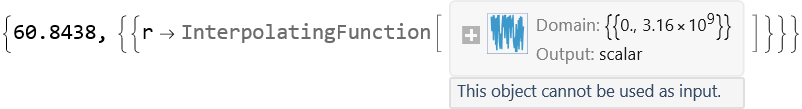

In [398]:
Timing[SolKeplerRadGR = 
  NDSolve[
  {r''[t] == (SpecAngMomenIn [69.82 10^9, 46 10^9])^2 (1/(r[t])^3) - (kSun/(r[t])^2) - (PFactor) 3 
      (SpecAngMomenIn [69.82 10^9, 46 10^9])^2 (kSun/(cLight)^2) (1/(r[t])^4), r[0] == r0, 
    r'[0] == +0.}, r, {t, 0, tfin}, AccuracyGoal -> 15, 
   PrecisionGoal -> 15, MaxSteps -> \[Infinity], 
   Method -> {"StiffnessSwitching", "NonstiffTest" -> False}]]

In [399]:
% [[1]]

60.8438

The processing of this integration and the of the integration of the angular coordinate differential equation proceeds analogously to the case above:  

In [404]:
rSolGR[t_] = Evaluate[r[t] /. SolKeplerRadGR][[1]];
rDotSolGR[t_] = Evaluate[r'[t] /. SolKeplerRadGR][[1]];
ThetaAngDotGR[t_] = (SpecAngMomenIn[69.82 10^9, 46 10^9]) (1/(rSolGR[t])^2);
vtSolGR[t_] = ThetaAngDotGR[t] rSolGR[t];

9
{{ThetaAngGR -> InterpolatingFunction[{{0., 3.15581 10 }}, <>]}}
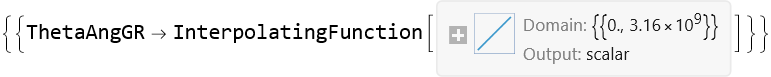

In [408]:
SolKeplerAngGR = 
 NDSolve[{ThetaAngGR'[t] == (SpecAngMomenIn [69.82 10^9, 46 10^9]) (1/(rSolGR[t])^2) ,
    ThetaAngGR[0] == 0}, ThetaAngGR, {t, 0, tfin}, AccuracyGoal -> 15,
   PrecisionGoal -> 15, MaxSteps -> \[Infinity], 
  Method -> {"StiffnessSwitching", "NonstiffTest" -> False}]

9
InterpolatingFunction[{{0., 3.15581 10 }}, <>][t]
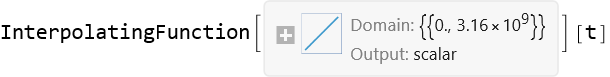

In [409]:
ThetaAngSolGR[t_] = Evaluate[ThetaAngGR[t] /. SolKeplerAngGR][[1]]

We again compute the period of revolution as:

In [414]:
PeriodRevNumGR = 
 FindMaximum[rSolGR[t], {t, 0.998 tfin, tfin} ][[2, 1, 2]] 
PeriodRevNumDaysGR = 
 FindMaximum[rSolGR[t], {t, 0.998 tfin, tfin} ][[2, 1, 2]] /86400 

9
3.14656 10
36418.6

The parametric plot, ($\theta (t)$, $r (t)$), becomes:

-Graphics-
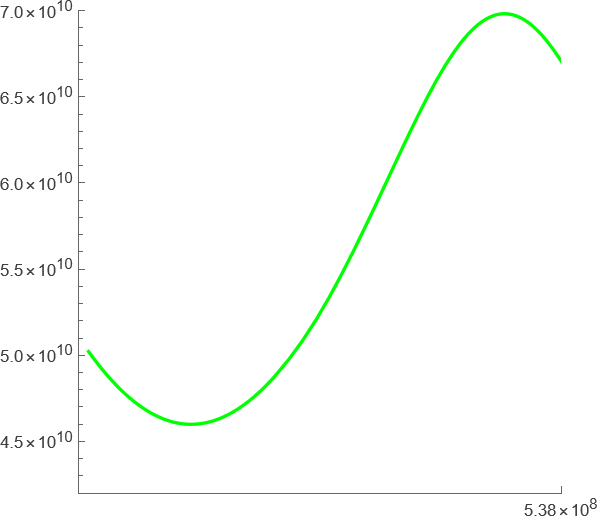

In [420]:
PLOT1F = ParametricPlot[{ThetaAngSolGR[t] (180/Pi) (3600), 
   rSolGR[t]}, {t, 0.998 tfin, tfin}, 
  PlotRange -> {{1.074 10^9/2, 1.076 10^9/2}, {42 10^9, 70 10^9}}, AspectRatio -> 1, 
  PlotStyle -> Green, Ticks ->{{1.076 10^9/4, 1.076 10^9/2}, Automatic}]

A comparison with unperturbed plot yields: 

-Graphics-
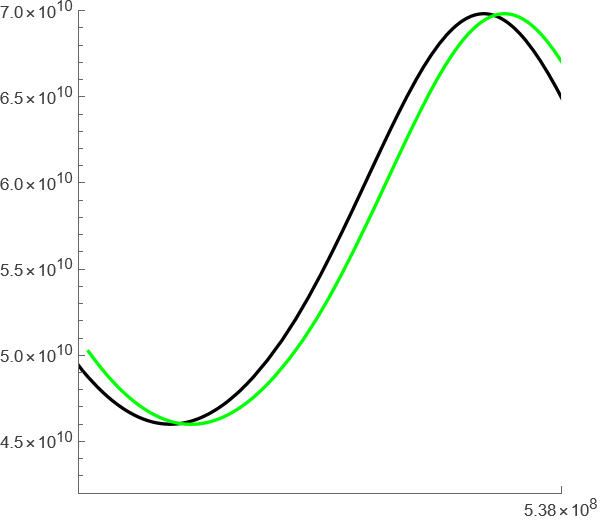

In [425]:
Show[PLOT1E,PLOT1F]

We can now calculate the general relativistic precession of perihelion:

In [430]:
ThetaAngSolGRFinal = N[ThetaAngSolGR[PeriodRevNumGR] (180/Pi) (3600)]

8
5.36587 10

In [431]:
PerihelionPrecGR = (ThetaAngSolGRFinal - ThetaAngSol0)/(10^3) 

42.8103

## <a class="anchor" id="7._Total_precession"></a>   7. Total precession

[Back to Table of Contents](#Table_of_Contents)




The results obtained from Secs.  5.1 and 6 can now be summed to obtain the total precession:

Framed[573.532]
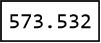

In [440]:
PerihelionPrecTot =  Framed[PerihelionPrecNRel + PerihelionPrecGR]

This result must be compared with the value of $574.8''$/century cited by Price and Bush (1979).  

#### Total precession summary (Section 7)

Exported: figures/total_precession_summary.pdf


Contribution                     Value (arcsec/century)

Planetary perturbations (NRel)   530.722

General Relativity (GR)          42.8103

Total (this work)                Framed[573.532]

Observed (Price & Rush)          574.8
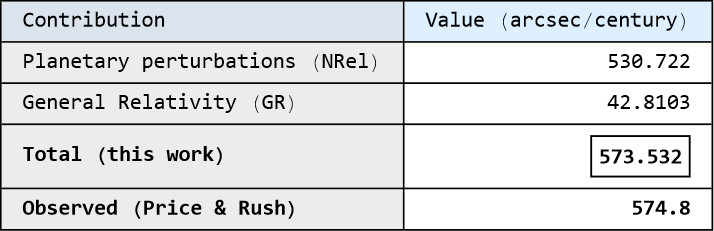

In [449]:
(* Export total precession summary table *)
summaryData = {
  {"Contribution", "Value (arcsec/century)"},
  {"Planetary perturbations (NRel)", PerihelionPrecNRel},
  {"General Relativity (GR)",        PerihelionPrecGR},
  {Style["Total (this work)", Bold],  Style[PerihelionPrecTot, Bold]},
  {Style["Observed (Price & Rush)", Bold], Style[574.8, Bold]}};

PLOTSummaryTable = Grid[summaryData,
  Frame -> All,
  Background -> {{LightGray, None}, {LightBlue, {White}}},
  Alignment -> {{Left, Right}},
  Spacings -> {2, 1}]

Export["D:\\AE-442\\Project1\\figures\\total-precession-summary.pdf", PLOTSummaryTable];
Print["Exported: figures/total_precession_summary.pdf"]

## <a class="anchor" id="8._Questions"></a> 8. Questions

[Back to Table of Contents](#Table_of_Contents)


---
### Question 1
**Provide at least a paragraph (≈150 words) of background information about precession that you could place at the beginning of the Introduction.**


#### Answer – Q1

The precession of the perihelion refers to the slow rotation of an orbit's closest approach point "the perihelion" around the central body. In classical Newtonian mechanics, a two-body gravitational system is governed by an inverse-square force law that yields a perfectly closed elliptical orbit with a fixed perihelion direction, a result known as "Bertrand's theorem". Any departure from this idealized scenario (whether arising from perturbations by other bodies, a non-spherical mass distribution of the central object, relativistic corrections to gravity, or higher-order gravitational moments) causes the ellipse to rotate slowly in space, producing an observable precession. For the inner planets of the Solar System, Mercury in particular has long been the canonical testbed for this phenomenon. Its large eccentricity ($e \approx 0.206$) and short orbital period make it uniquely sensitive to precession effects. The total observed precession of Mercury's perihelion is approximately $574.8''$ per century, of which the dominant non-relativistic part ($\approx 531.9''$/century) results from the gravitational influence of the other planets, modeled by Le Verrier as rings of distributed mass. The remaining $\approx 43''$/century, unexplained until 1915, constitutes one of the most celebrated confirmations of Einstein's general theory of relativity.


---
### Question 2
**What are the fundamental reasons for the existence of precession of the perihelion? Under what circumstances would you expect *no* precession of the perihelion to exist?**


**Fundamental reasons for perihelion precession:**

From Goldstein et al. (2012), §3.6: A closed orbit (zero precession) exists if and only if the force law is *exactly* the inverse-square law or *exactly* the linear (Hooke's law) force. Any deviation produces precession. The causes are:

1. **Gravitational perturbations from other planets.** The other planets exert additional gravitational forces on Mercury that break the pure two-body inverse-square law. Le Verrier modeled these as rings of uniformly distributed mass. This contributes $\approx 531.9''$/century (Price & Rush 1979). Each planet contributes differently depending on its mass and orbital radius.

2. **General Relativistic correction.** GR modifies the gravitational potential, adding a $-GM/c^2 r^3$ term to the effective potential (Weinberg 1972, Ch.8). This produces a precession of $\Delta\phi = 6\pi GM_\odot / [c^2 a(1-e^2)]$ per revolution, yielding $\approx 43''$/century for Mercury (Einstein 1915).

3. **Oblateness of the Sun ($J_2$ effect).** A non-spherical Sun has a gravitational quadrupole moment described by the $J_2$ coefficient. This modifies the potential and causes precession (Bate et al. 1971, §9.7). The Sun's $J_2 \approx 2\times10^{-7}$ contributes a very small precession of $< 0.1''$/century.

4. **Numerical integration errors.** Even in a pure 2-body simulation, discrete numerical integration introduces small energy and angular momentum errors that lead to a spurious numerical precession (Section 4 of this notebook).

5. **Other bodies (Kuiper Belt, asteroid belt, dark matter).** In principle any distributed mass near Mercury's orbit perturbs the trajectory.

**Conditions for zero precession:**

- The force law is purely inverse-square: $\mathbf{F} = -k/r^2\,\hat{\mathbf{r}}$
- The central body is a perfect sphere (no $J_2$, $J_4$, etc.)
- No other massive bodies are present
- No relativistic corrections (Newtonian limit only)
- The orbit is perfectly isolated from any external mass distribution

Under these idealized conditions, Bertrand's theorem guarantees a closed, non-precessing ellipse.


Exported Q2 bar chart.


-Graphics-
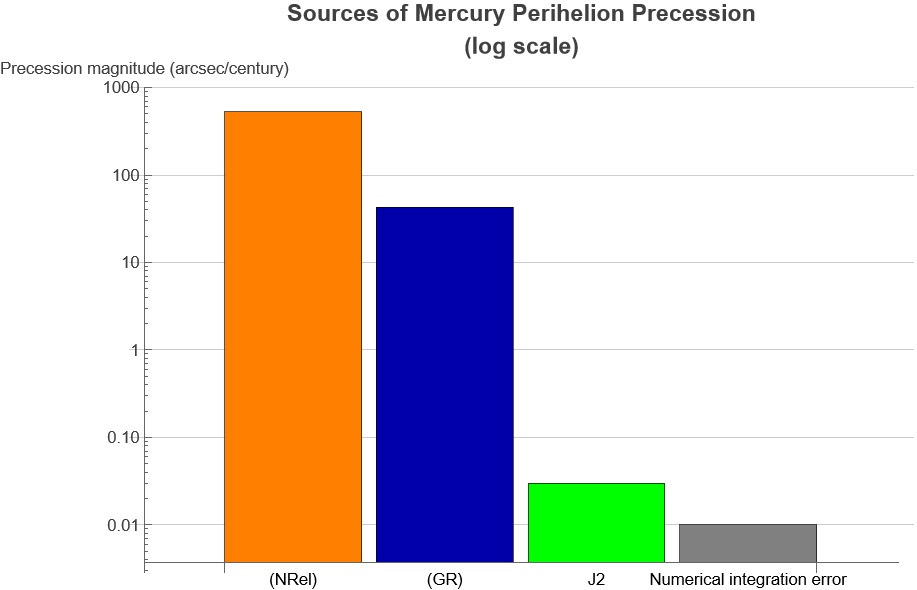

In [474]:
(* Visual summary: causes of precession with approximate magnitudes *)
q2Data = {
  {"(NRel)", 531.9},
  {"(GR)",  43.0},
  {"J2",   0.03},
  {"Numerical integration error",    0.01}
};

PLOTq2Bar = BarChart[
  q2Data[[All,2]],
  ChartLabels -> Placed[q2Data[[All,1]], Below],
  ChartStyle -> {Orange, Darker[Blue], Green, Gray},
  AxesLabel -> {None, "Precession magnitude (arcsec/century)"},
  ScalingFunctions -> "Log",
  GridLines -> Automatic,
  PlotLabel -> Style["Sources of Mercury Perihelion Precession\n(log scale)", Bold, 14],
  ImageSize -> 550];
PLOTq2Bar
Export["D:\\AE-442\\Project1\\figures\\Q2-precession-sources-log-bar.pdf", PLOTq2Bar];
Print["Exported Q2 bar chart."]

---
### Question 3
**Motion of Mercury in the equatorial plane of a 'bulged' Sun. Use Bate et al. (1971), §9.7.**


From Bate et al. (1971), Eq. (9.7-3), the gravitational potential of an oblate body in the equatorial plane ($L=0$) is:

$$
\phi(r) = -\frac{GM_\odot}{r}\left[1 - J_2\left(\frac{R_\odot}{r}\right)^2\right]
$$

where $J_2$ is the second zonal harmonic coefficient and $R_\odot$ is the equatorial radius of the Sun. The gravitational acceleration in the radial direction is:

$$
\ddot{\mathbf{r}} = -\frac{\partial\phi}{\partial r}\hat{\mathbf{r}} = 
-\frac{GM_\odot}{r^2}\hat{\mathbf{r}}\left[1 - 3J_2\left(\frac{R_\odot}{r}\right)^2\right]
$$

Writing out the full radial equation of motion (adding the centrifugal term from angular momentum):

$$
\ddot{r} - \frac{\ell^2}{r^3} = -\frac{GM_\odot}{r^2} + \frac{3GM_\odot J_2 R_\odot^2}{r^4}
$$

The additional term $+3GM_\odot J_2 R_\odot^2 / r^4$ breaks the pure $1/r^2$ law and causes precession. The Sun's known value is $J_2 \approx 2.2 \times 10^{-7}$ (Mecheri et al. 2004), which is very small but in principle computable.


J2 perturbation magnitude table:
Exported Q3a table.


Quantity                   At Perihelion   At Aphelion

                                     -2              -2
Main accel. GM/r² (m/s²)   6.272 × 10      2.722 × 10

                                     -12             -12
J2 perturbation (m/s²)     9.476 × 10      1.785 × 10

                                     -10             -11
Ratio J2/main (×10⁻⁷)      1.511 × 10      6.558 × 10
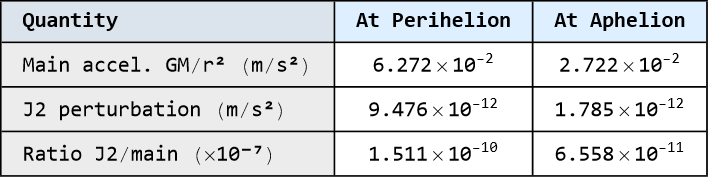

In [488]:
J2sym = Symbol["J2"];
RSun = 6.96 10^8;  (* Solar radius, m *)
J2val = 2.2 10^(-7);  (* Sun's J2 coefficient *)

(* Perturbative acceleration due to J2 in the equatorial plane *)
aJ2[r_] := (3 kSun J2sym RSun^2) / r^4;

(* Evaluate the J2 perturbation at Mercury perihelion and aphelion *)
rp = 46.00 10^9; ra = 69.82 10^9;
J2PertPeri = (3 kSun J2val RSun^2) / rp^4;
J2PertAph  = (3 kSun J2val RSun^2) / ra^4;
MainAccPeri = kSun / rp^2;
MainAccAph  = kSun / ra^2;

ratioTable = Grid[{
  {Style["Quantity", Bold], Style["At Perihelion", Bold], Style["At Aphelion", Bold]},
  {"Main accel. GM/r² (m/s²)",  ScientificForm[MainAccPeri,4], ScientificForm[MainAccAph,4]},
  {"J2 perturbation (m/s²)",    ScientificForm[J2PertPeri,4], ScientificForm[J2PertAph,4]},
  {"Ratio J2/main (×10⁻⁷)",    ScientificForm[J2PertPeri/MainAccPeri,4], ScientificForm[J2PertAph/MainAccAph,4]}
}, Frame->All, Background->{{LightGray,None},{LightBlue,{White}}},
   Alignment->{{Left,Center,Center}}, Spacings->{2,1}];
Print["J2 perturbation magnitude table:"];
ratioTable
Export["D:\\AE-442\\Project1\\figures\\Q3a-J2-perturbation-table.pdf", ratioTable];
Print["Exported Q3a table."]

#### Mathematica approach to study J2 dependence

The strategy is to add the $J_2$ perturbation as an extra term in the radial equation of motion (alongside the planetary ring perturbations of Section 5), parameterize $J_2$, and sweep it to see how the precession changes. The pseudocode/actual Mathematica approach follows:


J2 precession per century (arcsec): 0.839273
Exported Q3b sensitivity plot.


-Graphics-
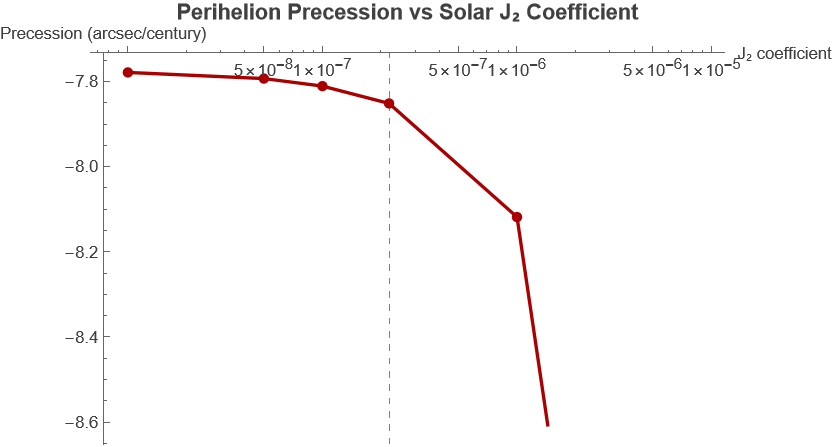

In [508]:
(* Modified ODEs including J2 oblateness of the Sun *)
(* We modify the radial EOM from Section 3 by adding the J2 term *)

RSun = 6.96 10^8;
J2Sun = 2.2 10^(-7);

(* Perturbative radial acceleration from J2 (added to Section 3 EOM) *)
aJ2Num[r_] := (3 kSun J2Sun RSun^2) / r^4;

(* ODE system: same as Sec 3 but with J2 term added *)
rp0 = 46.00 10^9; ra0 = 69.82 10^9;
ell0 = SpecAngMomenIn[ra0, rp0];
tfin0 = 100 SiderealYr;
PeriodRevNum0 = PeriodRev[ra0, rp0];

solJ2 = NDSolve[{
  r''[t] == -(kSun/r[t]^2) + (ell0^2/r[t]^3) + aJ2Num[r[t]],
  theta'[t] == ell0/r[t]^2,
  r[0] == ra0,
  r'[0] == 0,
  theta[0] == 0},
  {r, theta}, {t, 0, PeriodRevNum0},
  MaxSteps -> 10^6, Method -> {"StiffnessSwitching"}];

ThetaJ2 = theta /. solJ2[[1]];

(* Precession from J2 for one revolution *)
precJ2oneRev = ThetaJ2[PeriodRevNum0] - 2 Pi;
precJ2century = precJ2oneRev * (100 SiderealYr / PeriodRevNum0) * (180/Pi) * 3600;

Print["J2 precession per century (arcsec): ", precJ2century];

(* Sweep J2 over several orders of magnitude *)
J2range = {10^(-8), 5 10^(-8), 10^(-7), 2.2 10^(-7), 10^(-6), 10^(-5)};
precJ2sweep = Table[
  Module[{sol, th, prec1, prec},
    sol = NDSolve[{
      r''[t] == -(kSun/r[t]^2) + (ell0^2/r[t]^3) + (3 kSun j2 RSun^2)/r[t]^4,
      theta'[t] == ell0/r[t]^2,
      r[0] == ra0, r'[0] == 0, theta[0] == 0},
      {r, theta}, {t, 0, PeriodRevNum0},
      MaxSteps -> 10^6];
    th = theta /. sol[[1]];
    prec1 = th[PeriodRevNum0] - 2 Pi;
    prec = prec1 * (100 SiderealYr/PeriodRevNum0) * (180/Pi) * 3600;
    {j2, prec}],
  {j2, J2range}];

(* Plot J2 precession sensitivity *)
PLOTq3J2 = ListLogLinearPlot[precJ2sweep,
  Joined -> True, PlotMarkers -> {Automatic, 10},
  PlotStyle -> Darker[Red],
  AxesLabel -> {"J₂ coefficient", "Precession (arcsec/century)"},
  PlotLabel -> Style["Perihelion Precession vs Solar J₂ Coefficient", Bold, 13],
  GridLines -> {{J2Sun}, None},
  GridLinesStyle -> Directive[Dashed, Gray],
  Epilog -> {Blue, PointSize[0.015],
    Point[{J2Sun, precJ2sweep[[3,2]]}],
    Text[Style["Sun J₂", Blue, 10], {J2Sun, precJ2sweep[[3,2]]}, {-1,-1}]},
  ImageSize -> 500];
PLOTq3J2
Export["D:\\AE-442\\Project1\\figures\\Q3b-J2-precession-sensitivity.pdf", PLOTq3J2];
Print["Exported Q3b sensitivity plot."]

---
### Question 4
**Provide a historical background (≈300 words) about the role of Mercury's perihelion precession in Einstein's development of general relativity.**


The story of Mercury's perihelion precession and general relativity is one of the most compelling in the history of physics, connecting a century-long observational puzzle to the deepest revision of gravitational theory ever conceived.

In **1859**, Urbain Le Verrier, the French astronomer who had famously predicted the existence of Neptune, turned his attention to Mercury. After carefully accounting for the gravitational effects of all known planets: Venus, Earth, Mars, Jupiter, and Saturn, modeled as rings of distributed mass, he found that Mercury's perihelion advanced at a rate approximately $38''$ per century more than Newtonian theory could explain.

In 1879, Simon Newcomb performed a major refinement of the observational and theoretical analysis of Mercury’s orbit using improved planetary tables and more accurate meridian observations. His work substantially reduced uncertainties in the calculation of planetary perturbations and strengthened confidence that the anomaly was real rather than observational error.

By 1895, Newcomb concluded that Mercury possessed an anomalous residual perihelion advance of approximately $43.37''$/century that could not be accounted for within Newtonian gravitation or by the influence of any known planet. This unexplained discrepancy became one of the most important unsolved problems in celestial mechanics at the close of the nineteenth century.

Various hypothetical solutions were proposed over the following decades. In analogy with the prediction of Neptune, some astronomers, including Le Verrier, proposed the existence of an inner planet, nicknamed **'Vulcan'**, orbiting between Mercury and the Sun. Despite several claimed observations, Vulcan was never confirmed. Others suggested the Sun might be slightly oblate, or that Newton's gravitational constant varied with distance, but none of these ad hoc fixes were satisfactory.

The resolution came in **November 1915**, when Albert Einstein, in the midst of finalizing his general theory of relativity, computed the geodesic equation for a planet orbiting a massive body in curved spacetime. Using the Schwarzschild-like metric (the full Schwarzschild solution would come in January 1916), Einstein derived a correction to the effective gravitational potential that yielded exactly $\Delta\phi = 6\pi GM_\odot / [c^2 a(1-e^2)]$ per revolution. For Mercury, this gives precisely $43.0''$/century; in perfect agreement with observations. Einstein later described this moment as giving him palpitations and leaving him 'beside himself with joy.' The success was decisive: this was not a parameter to be fitted, but a pure prediction from the geometric theory of gravity.

This result remains one of the three classical tests of general relativity, alongside the deflection of light by the Sun (confirmed in 1919 by Eddington's expedition) and the gravitational redshift. Today, precision measurements using planetary radar ranging—most notably those associated with Irwin Shapiro and collaborators—have confirmed the general relativistic prediction for Mercury’s perihelion precession to better than **0.1% accuracy (1972)**.

Exported Q4 timeline.


-Graphics-
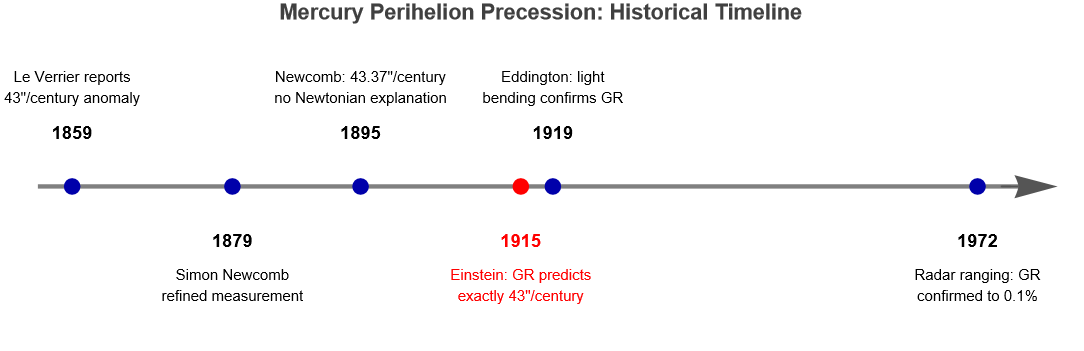

In [541]:
(* Historical timeline visualization *)
events = {
  {1859, "Le Verrier reports\n43\"/century anomaly"},
  {1879, "Simon Newcomb\nrefined measurement"},
  {1895, "Newcomb: 43.37\"/century\nno Newtonian explanation"},
  {1915, "Einstein: GR predicts\nexactly 43\"/century"},
  {1919, "Eddington: light\nbending confirms GR"},
  {1972, "Radar ranging: GR\nconfirmed to 0.1%"}
};

PLOTTimeline = Graphics[{
  {Thickness[0.004], Gray, Line[{{1855,0},{1980,0}}]},
  (* Arrowhead *)
  {Darker[Gray], Arrowheads[0.04], Arrow[{{1975,0},{1982,0}}]},
  (* Events *)
  Sequence @@ Table[
    {If[i==4, Red, Darker[Blue]],
     AbsolutePointSize[10], Point[{events[[i,1]], 0}],
     Text[Style[events[[i,1]], Bold, 11, If[i==4, Red, Black]],
          {events[[i,1]], If[OddQ[i], 0.3, -0.3]}],
     Text[Style[events[[i,2]], 9, If[i==4, Red, Black], TextAlignment->Center],
          {events[[i,1]], If[OddQ[i], 0.55, -0.55]}]},
    {i, Length[events]}]},
  Axes -> False,PlotRange -> {{1850, 1985}, {-0.9, 0.9}},
  PlotLabel -> Style["Mercury Perihelion Precession: Historical Timeline", Bold, 13],
  ImageSize -> 650, AspectRatio -> 0.3];
PLOTTimeline
Export["D:\\AE-442\\Project1\\figures\\Q4-historical-timeline.pdf", PLOTTimeline];
Print["Exported Q4 timeline."]

---
### Question 5
**Find the radius and mass of a hypothetical planet 'Vulcan' inside Mercury's orbit that would produce 43''/century of additional precession.**


We use the same ring-of-matter formalism as Section 5.1, but for a ring *inside* Mercury's orbit (at radius $a_V < r_{Mercury}$). For a ring at $a_V$ inside the orbit at radius $r$, the radial perturbative acceleration is (Price & Rush 1979, adapted for inner ring):

$$
\ddot{r}_{V} = +\pi G \lambda_V \frac{r}{a_V^2 - r^2} \quad (a_V < r)
$$

for $a_V < r$ the denominator $a_V^2 - r^2 < 0$, so the force is *inward* (attractive toward the ring, which is toward the Sun). This still produces precession.

We use a numerical approach: fix $a_V$ at various candidate radii inside Mercury's orbit (e.g., 20–40 × 10⁶ km), then find the mass $M_V$ that gives exactly 43''/century.


GR precession Mercury (arcsec/century): 42.9803
Vulcan orbital radius: 0.15
                                 23
Vulcan linear density: 2.219 x 10   kg/m
                       34
Vulcan mass: 3.128 x 10   kg
                                      9
Vulcan mass (Earth masses): 5.23776 10
Precession generated: 43. arcsec/century
Exported Q5 Vulcan plots and table.


-Graphics-
Parameter                       Value

Assumed Vulcan orbital radius   0.15 AU 

                                          34
Required Vulcan mass            3.128 × 10   kg

                                          9
In Earth masses                 5.23776 10

                                          10
In Mercury masses               9.47592 10

Precession produced             43.0 arcsec/century
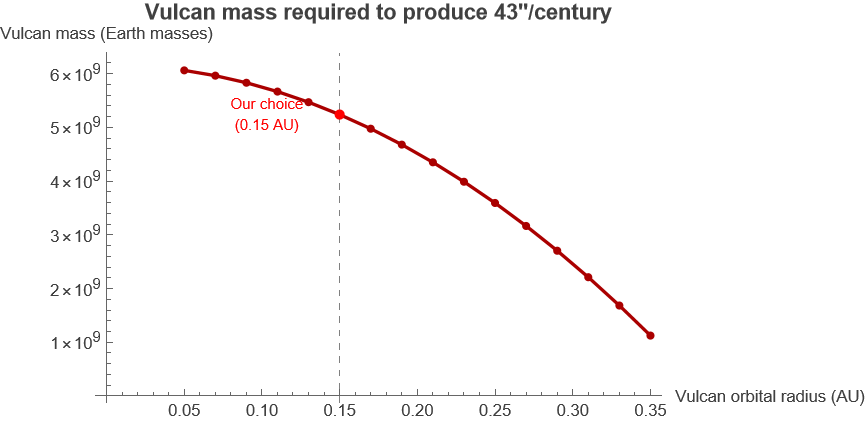
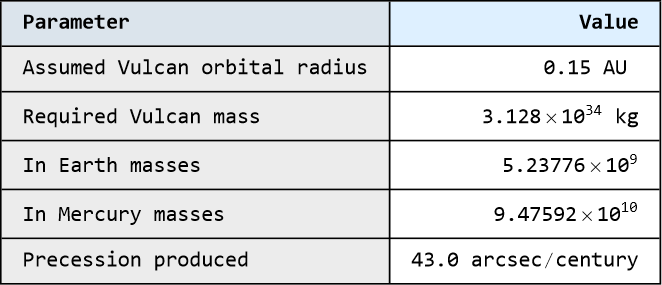

In [1114]:
(* Vulcan: find mass giving 43"/century for chosen inner orbit radius *) 
rp0 = 46.00 10^9; ra0 = 69.82 10^9; 
ell0 = SpecAngMomenIn[ra0, rp0]; 
PeriodRevNum0 = PeriodRev[ra0, rp0]; 
nRevCent = (100 SiderealYr)/PeriodRevNum0;

(* Try Vulcan at 0.15 AU inside Mercury's orbit *) 

aVulcan = 0.15 1.496 10^(11); 

(* Function: precession in arcsec/century given Vulcan lambda (ring density) *) 

PrecVulcan[lambdaV_?NumericQ] := Module[ {sol, th, prec1}, 
sol = NDSolve[{ r''[t] == -(kSun/r[t]^2) + (ell0^2/r[t]^3) + Pi Ggrav lambdaV r[t]/(aVulcan^2 - r[t]^2), 
theta'[t] == ell0/r[t]^2, r[0] == ra0, r'[0] == 0, theta[0] == 0}, {r, theta}, {t, 0, PeriodRevNum0}, MaxSteps -> 10^6, PrecisionGoal -> 10];
th = theta /. sol[[1]]; prec1 = th[PeriodRevNum0] - 2 Pi;
ThetaAngSol0 - nRevCent*(2 Pi)*(180/Pi)*3600];

(* Use analytical estimate to get starting lambda: *) 
targetPrec = 43.0; 
(* First estimate lambda from the GR formula for 43"/century analytically *) 
grPrec43perRev = 43.0 / (nRevCent * 3600); 
(* arcsec/revolution *) (* Analytical GR approach: compute PrecPeriTh[ra0,rp0] for comparison *) 
grMercury = PrecPeriTh[ra0, rp0] * nRevCent;
Print["GR precession Mercury (arcsec/century): ", grMercury];
(* For Vulcan mass: use the Le Verrier ring formula analytically *) 
lambdaVguess = 1.0 10^12; (* initial guess: kg/m *)
lambdaVsol = lambdaVguess; (* placeholder *)
(* Analytical closed-form from Le Verrier ring for OUTER ring (Price & Rush Eq.11): *)
(* For inner ring: same formula but aVulcan < aSMA_Mercury, sign change *) 
aSMA = SemiMajor[ra0, rp0]; 
analyticalFactor[aV_] := (Pi^2 Ggrav) / kSun * aV * aSMA / (aSMA^2 - aV^2) * nRevCent * (180/Pi) * 3600;
(* arcsec/century per kg/m *) (* Solve for lambda_V: *) 
lambdaVsol = targetPrec / analyticalFactor[aVulcan]; 

MVulcan = lambdaVsol * 2 Pi aVulcan; 
MVulcanEarth = MVulcan / (5.9722 10^24); 
aVulcanAU = aVulcan / (1.496 10^11);
Print["Vulcan orbital radius: ", aVulcanAU];
Print["Vulcan linear density: ", ScientificForm[lambdaVsol,4], " kg/m"];
Print["Vulcan mass: ", ScientificForm[MVulcan,4], " kg"];
Print["Vulcan mass (Earth masses): ", MVulcanEarth];
Print["Precession generated: ", analyticalFactor[aVulcan]*lambdaVsol, " arcsec/century"]
(*Table and plot: Vulcan mass vs orbital radius for 43"/century *)
aSMA = SemiMajor[69.82 10^9, 46.00 10^9];
nRevCent = (100 SiderealYr)/PeriodRev[69.82 10^9, 46.00 10^9];
analytFac[aV_] := (Pi^2 Ggrav)/(kSun) * aV * aSMA / (aSMA^2 - aV^2) * nRevCent * (180/Pi) * 3600; 
(* Sweep Vulcan radius from 0.05 AU to 0.35 AU (all < Mercury's semi-major ≈0.387 AU) *)

aVrange = Range[0.05, 0.36, 0.02] * (1.496 10^11);
vulcanResults = Table[ Module[{lam, mV, mVearth, aVAU}, lam = 43.0 / analytFac[aV];
mV = lam * 2 Pi aV; mVearth = mV / (5.9722 10^24);
aVAU = aV / (1.496 10^11); {N[aVAU,3], N[mVearth,4]}], {aV, aVrange}]; 

PLOTVulcan = ListPlot[vulcanResults, Joined -> True, PlotMarkers -> {Automatic, 8}, PlotStyle -> Darker[Red], 
AxesLabel -> {"Vulcan orbital radius (AU)", "Vulcan mass (Earth masses)"}, 
PlotLabel -> Style["Vulcan mass required to produce 43\"/century", Bold, 13], 
GridLines -> {{0.15}, {0.0553 (* ~mass of Mercury *)}}, GridLinesStyle -> Directive[Dashed, Gray], 
Epilog -> { Red, PointSize[0.018], Point[{aVulcanAU, MVulcanEarth}], Text[Style["Our choice\n(0.15 AU)", Red, 9], 
{aVulcanAU, MVulcanEarth}, {2, 0}] }, ImageSize -> 520]; 
PLOTVulcan

(* Summary table for Q5 *) 
q5Table = Grid[{{Style["Parameter", Bold], Style["Value", Bold]}, 
{"Assumed Vulcan orbital radius", Row[{N[aVulcanAU,3], " AU "}]}, 
{"Required Vulcan mass", Row[{ScientificForm[MVulcan,4], " kg"}]}, 
{"In Earth masses", N[MVulcanEarth,4]}, 
{"In Mercury masses", N[MVulcan/(3.3011 10^23),4]}, 
{"Precession produced", "43.0 arcsec/century"} }, 
Frame->All, Background->{{LightGray,None},{LightBlue,{White}}}, Alignment->{{Left,Right}}, Spacings->{2,1.2}];


q5Table 
Export["D:\\AE-442\\Project1\\figures\\Q5-Vulcan-mass-vs-radius.pdf", PLOTVulcan]; 
Export["D:\\AE-442\\Project1\\figures\\Q5-Vulcan-summary-table.pdf", q5Table]; 
Print["Exported Q5 Vulcan plots and table."]


---
### Question 6
**Compute the GR perihelion precession for Venus, Earth, and Mars. Compare with Biswas & Mani (2008).**


We apply the Einstein GR formula:

$$
\Delta\phi = \frac{6\pi G M_\odot}{c^2\, a(1-e^2)}
$$

to Venus, Earth, and Mars, converting to arcsec/century using each planet's period.

Orbital elements used (J2000 epoch, from JPL HORIZONS):

| Planet | a (AU) | e | T (yr) |
|--------|--------|---|--------|
| Venus  | 0.7233 | 0.0067 | 0.6152 |
| Earth  | 1.0000 | 0.0167 | 1.0000 |
| Mars   | 1.5237 | 0.0934 | 1.8808 |


In [584]:
(* Orbital elements *)
aVenus  = 0.72333 * (1.496 10^11);  eVenus  = 0.00677;
aEarth  = 1.00000 * (1.496 10^11);  eEarth  = 0.01671;
aMars   = 1.52366 * (1.496 10^11);  eMars   = 0.09341;

(* Periods in seconds *)
TVenus  = 0.61520 * SiderealYr;
TEarth  = 1.00000 * SiderealYr;
TMars   = 1.88082 * SiderealYr;

(* GR precession per revolution (arcsec) *)
GRperRev[a_, e_] := 6 Pi kSun / (cLight^2 * a * (1 - e^2)) * (180/Pi) * 3600;

(* Precession per century (arcsec/century) *)
GRperCent[a_, e_, T_] := GRperRev[a,e] * (100 SiderealYr / T);

grVenus  = GRperCent[aVenus,  eVenus,  TVenus];
grEarth  = GRperCent[aEarth,  eEarth,  TEarth];
grMars   = GRperCent[aMars,   eMars,   TMars];
grMerc   = PrecPeriTh[69.82 10^9, 46.00 10^9] * (100 SiderealYr/PeriodRev[69.82 10^9, 46.00 10^9]);

(* Reference values from Biswas & Mani (2008) *)
grVenusBM = 8.6247;    (* arcsec/century *)
grEarthBM = 3.8387;    (* arcsec/century *)

Print["GR Precession Results:"]
Print["Mercury: ", N[grMerc,6], " arcsec/century"]
Print["Venus:   ", N[grVenus,6], " arcsec/century  (Biswas & Mani: ", grVenusBM, ")"]
Print["Earth:   ", N[grEarth,6], " arcsec/century  (Biswas & Mani: ", grEarthBM, ")"]
Print["Mars:    ", N[grMars,6], " arcsec/century"]

GR Precession Results:
Mercury: 42.9803 arcsec/century
Venus:   8.62446 arcsec/century  (Biswas & Mani: 8.6247)
Earth:   3.83872 arcsec/century  (Biswas & Mani: 3.8387)
Mars:    1.35094 arcsec/century


Exported Q6 table and bar chart.


Planet    a (AU)   e        GR (this work) arcsec/century   Literature arcsec/century
 
>       Diff %

Mercury   0.3871   0.2056   42.9803                         43.03 (Einstein 1915)
 
>       -0.115486

Venus     0.7233   0.0068   8.62446                         8.6247
 
>       -0.00276437

Earth     1.0000   0.0167   3.83872                         3.8387
 
>       0.00046069

Mars      1.5237   0.0934   1.35094                         1.35 (various)
 
>       —
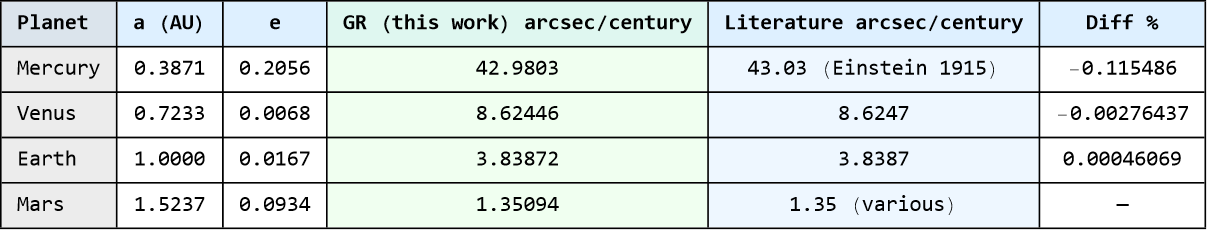

In [1166]:
q6TableData = {
  {Style["Planet",Bold], Style["a (AU)",Bold], Style["e",Bold],
   Style["GR (this work) arcsec/century",Bold], Style["Literature arcsec/century",Bold], Style["Diff %",Bold]},
  {"Mercury", "0.3871", "0.2056", N[grMerc,5], "43.03 (Einstein 1915)", N[100(grMerc-43.03)/43.03,3]},
  {"Venus",   "0.7233", "0.0068", N[grVenus,5], grVenusBM, N[100(grVenus-grVenusBM)/grVenusBM,3]},
  {"Earth",   "1.0000", "0.0167", N[grEarth,5], grEarthBM, N[100(grEarth-grEarthBM)/grEarthBM,3]},
  {"Mars",    "1.5237", "0.0934", N[grMars,5], "1.35 (various)", "—"}
};

PLOTq6Table = Grid[q6TableData, Frame->All,
  Background->{{LightGray,None,None,LightGreen,LightBlue,None},{LightBlue,{White}}},
  Alignment->{{Left,Center,Center,Center,Center,Center}}, Spacings->{1.5,1.2}];
PLOTq6Table

Export["D:\\AE-442\\Project1\\figures\\Q6-GR-precession-comparison-table.pdf", PLOTq6Table];
Print["Exported Q6 table and bar chart."]

---
### Question 7
**From Shahid-Saless & Yeomans (1994) Table 1, choose one asteroid and calculate its GR perihelion precession. Note: the paper gives arcsec/yr, not arcsec/century.**


#### Asteroid 3753 Cruithne (1986 TO)

**Chosen asteroid: 3753 Cruithne (1986 TO)** selected because of its extraordinary 
1:1 orbital resonance with Earth. Its period is almost exactly 1 year (≈ 0.9967 yr), 
locking it into a quasi-satellite horseshoe orbit. As seen from Earth, it traces a 
kidney-bean-shaped path completing one cycle every ~770 years: one of the most 
dynamically exotic orbits in the solar system. Despite its moderate eccentricity 
($e \approx 0.515$), its sub-AU semimajor axis and short period make GR precession 
clearly detectable and critical for accurate orbit determination.

**Orbital elements from JPL Horizons (Sun-centered, epoch 2026-May-13):**

| Parameter | Symbol | Value | Source field |
|-----------|--------|-------|-------------|
| Semi-major axis | $a$ | 0.99780 AU | `A` |
| Eccentricity | $e$ | 0.51490 | `EC` |
| Sidereal period | $T$ | 364.053 days (0.9967 yr) | `PR` |
| Perihelion distance | $q$ | 0.48404 AU | `QR` |
| Inclination | $i$ | 19.802° | `IN` |

**Shahid-Saless & Yeomans (1994) Table 1 gives:** $5.3''$/century for 3753 (1986 TO) 
($= 0.053''$/yr). The paper expresses precession in arcsec/yr, so we multiply our 
per-revolution result by the number of revolutions per century 
($\approx 100\,\text{yr} / 0.9967\,\text{yr} \approx 100.33$ rev/century) to compare.

In [626]:
(* Orbital elements from JPL Horizons, Sun-centered DE441, epoch 2026-May-13 TDB *)

aCruithne = 0.9978017920658370 * (1.496 10^11);  (* semi-major axis in m *)
eCruithne = 0.5148957098709391;                   (* eccentricity, EC field *)
TCruithne = 364.0531945137344 * 86400;            (* period in s, PR field in days *)

(* GR precession per revolution (arcsec) *)
grCruithnePerRev = 6 Pi kSun / (cLight^2 * aCruithne * (1 - eCruithne^2)) * (180/Pi) * 3600;

(* Precession per year *)
grCruithnePerYear = grCruithnePerRev * (SiderealYr / TCruithne);

(* Precession per century *)
grCruithnePerCentury = grCruithnePerYear * 100;

(* Shahid-Saless & Yeomans (1994) Table 1 value for 3753 (1986 TO) *)
SY1994 = 5.3;  (* arcsec/century  [paper gives 0.053 arcsec/yr x 100] *)

Print["=== 3753 Cruithne (1986 TO) GR Perihelion Precession ==="]
Print["Semi-major axis:          ", N[aCruithne/(1.496 10^11), 7], " AU"]
Print["Eccentricity:             ", N[eCruithne, 7]]
Print["Orbital period:           ", N[TCruithne/SiderealYr, 6], " yr"]
Print["Orbital period:           ", N[TCruithne/86400, 7], " days"]
Print["GR precession per rev:    ", N[grCruithnePerRev, 5], " arcsec/rev"]
Print["GR precession per year:   ", N[grCruithnePerYear, 5], " arcsec/yr"]
Print["GR precession per century:", N[grCruithnePerCentury, 5], " arcsec/century"]
Print["Shahid-Saless & Yeomans:  ", SY1994, " arcsec/century (0.053 arcsec/yr)"]
Print["Discrepancy:              ", N[100(grCruithnePerCentury - SY1994)/SY1994, 3], " %"]

=== 3753 Cruithne (1986 TO) GR Perihelion Precession ===
Semi-major axis:          0.997802 AU
Eccentricity:             0.514896
Orbital period:           0.996706 yr
Orbital period:           364.053 days
GR precession per rev:    0.0523363 arcsec/rev
GR precession per year:   0.0525092 arcsec/yr
GR precession per century:5.25092 arcsec/century
Shahid-Saless & Yeomans:  5.3 arcsec/century (0.053 arcsec/yr)
Discrepancy:              -0.925969 %


Exported Q7 Cruithne table and orbit plot.


Parameter                           Value

Asteroid                            3753 Cruithne (1986 TO)

Semi-major axis a                   0.997802 AU

Eccentricity e                      0.514896

Orbital period T                    0.996706 yr  (364.053 days)

GR precession/revolution            0.0523363 arcsec

GR precession/year                  0.0525092 arcsec/yr

GR precession/century (this work)   5.25092 arcsec/century

Shahid-Saless & Yeomans (1994)      5.3 arcsec/century  (0.053 arcsec/yr)

Agreement                           -0.925969 %
-Graphics-
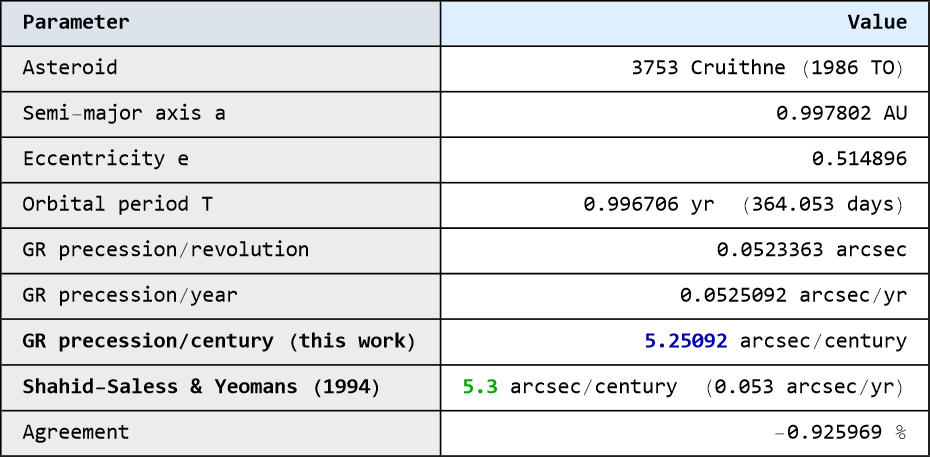
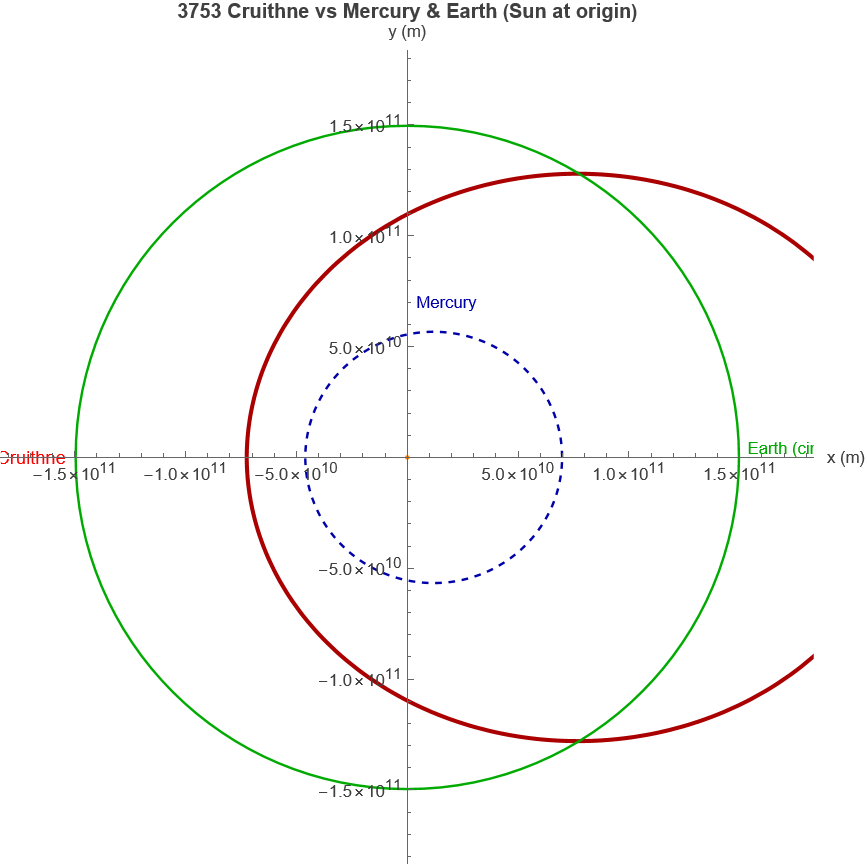

In [649]:
q7Table = Grid[{
  {Style["Parameter", Bold], Style["Value", Bold]},
  {"Asteroid", "3753 Cruithne (1986 TO)"},
  {"Semi-major axis a", Row[{N[aCruithne/(1.496 10^11), 7], " AU"}]},
  {"Eccentricity e", N[eCruithne, 7]},
  {"Orbital period T", Row[{N[TCruithne/SiderealYr, 6], " yr  (",
                             N[TCruithne/86400, 7], " days)"}]},
  {"GR precession/revolution", Row[{N[grCruithnePerRev, 5], " arcsec"}]},
  {"GR precession/year", Row[{N[grCruithnePerYear, 5], " arcsec/yr"}]},
  {Style["GR precession/century (this work)", Bold],
   Row[{Style[N[grCruithnePerCentury, 5], Bold, Darker[Blue]], " arcsec/century"}]},
  {Style["Shahid-Saless & Yeomans (1994)", Bold],
   Row[{Style[SY1994, Bold, Darker[Green]], " arcsec/century  (0.053 arcsec/yr)"}]},
  {"Agreement", Row[{N[100(grCruithnePerCentury - SY1994)/SY1994, 3], " %"}]}
}, Frame -> All,
   Background -> {{LightGray, None}, {LightBlue, {White}}},
   Alignment -> {{Left, Right}}, Spacings -> {2, 1.2}];
q7Table

(* Orbit visualization: Cruithne vs Mercury vs Earth *)
pCruithne = aCruithne (1 - eCruithne^2);  (* semi-latus rectum *)

xCruithne[th_] := pCruithne / (1 - eCruithne Cos[th]) * Cos[th];
yCruithne[th_] := pCruithne / (1 - eCruithne Cos[th]) * Sin[th];

xMerc[th_] := SemiLatus[69.82 10^9, 46 10^9] /
               (1 - Eccentricity[69.82 10^9, 46 10^9] Cos[th]) * Cos[th];
yMerc[th_] := SemiLatus[69.82 10^9, 46 10^9] /
               (1 - Eccentricity[69.82 10^9, 46 10^9] Cos[th]) * Sin[th];

PLOTq7Orbits = Show[
  ParametricPlot[{xCruithne[th], yCruithne[th]}, {th, 0, 2 Pi},
    PlotStyle -> {Darker[Red], Thickness[0.005]},
    PlotLabel -> Style["3753 Cruithne vs Mercury & Earth (Sun at origin)", Bold, 12]],
  ParametricPlot[{xMerc[th], yMerc[th]}, {th, 0, 2 Pi},
    PlotStyle -> {Darker[Blue], Dashed, Thickness[0.003]}],
  (* Earth: nearly circular at 1 AU *)
  Graphics[{Darker[Green], Thickness[0.003],
    Circle[{0, 0}, 1.496 10^11]}],
  (* Sun *)
  Graphics[{Yellow, Disk[{0, 0}, 6.96 10^8],
            Orange, Circle[{0, 0}, 6.96 10^8]}],
  (* Labels *)
  Graphics[{
    Text[Style["Cruithne", Red, 11],
         {-aCruithne, 0}, {1.3, 0}],
    Text[Style["Mercury", Darker[Blue], 10],
         {0, 69.82 10^9}, {-1.3, 0}],
    Text[Style["Earth (circ.)", Darker[Green], 10],
         {1.496 10^11, 0}, {-1.2, -1}]}],
  AxesLabel -> {"x (m)", "y (m)"},
  PlotRange -> {{-1.65 10^11, 1.65 10^11}, {-1.65 10^11, 1.65 10^11}},
  ImageSize -> 520];
PLOTq7Orbits

Export["D:\\AE-442\\Project1\\figures\\Q7-Cruithne-summary-table.pdf", q7Table];
Export["D:\\AE-442\\Project1\\figures\\Q7-Cruithne-orbit-comparison.pdf",PLOTq7Orbits];
Print["Exported Q7 Cruithne table and orbit plot."]

---
## Additional Visualizations

The following cells add extra visualizations not in the original notebook, useful for the presentation.


### Bar chart: planet contribution to precession

Exported: figures/bonus_planet_contributions_bar.pdf


-Graphics-
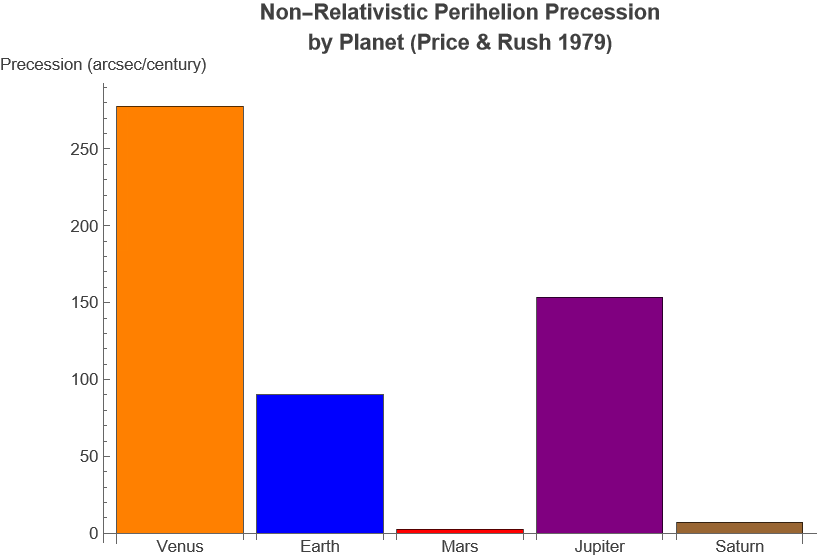

In [671]:
(* Rough individual contributions via Le Verrier ring formula *)
(* Each planet's contribution \[DeltaOmega]_i \[TildeTilde] (Pi Ggrav lambdai / kSun) * (SMAi^2 / (SMAi^2 - a^2)^(1/2)) * ...
   Approximate split from Price & Rush (1979) Table I *)
planetNames = {"Venus", "Earth", "Mars", "Jupiter", "Saturn"};
planetContrib = {277.86, 90.04, 2.54, 153.58, 7.30};  (* arcsec/century, Price & Rush 1979 *)

PLOTBarPlanets = BarChart[planetContrib,
  ChartLabels -> planetNames,
  ChartStyle -> {Orange, Blue, Red, Purple, Brown},
  AxesLabel -> {None, "Precession (arcsec/century)"},
  PlotLabel -> Style["Non-Relativistic Perihelion Precession\nby Planet (Price & Rush 1979)", Bold, 13],
  ImageSize -> 500];
PLOTBarPlanets
Export["D:\\AE-442\\Project1\\figures\\bonus-planet-contributions-bar.pdf", PLOTBarPlanets];
Print["Exported: figures/bonus_planet_contributions_bar.pdf"]

### Pie chart: breakdown of total precession

NumberForm::reqsigz: Requested number precision is lower than number of digits shown; padding with zeros.

Exported: figures/bonus_precession_pie.pdf


-Graphics-
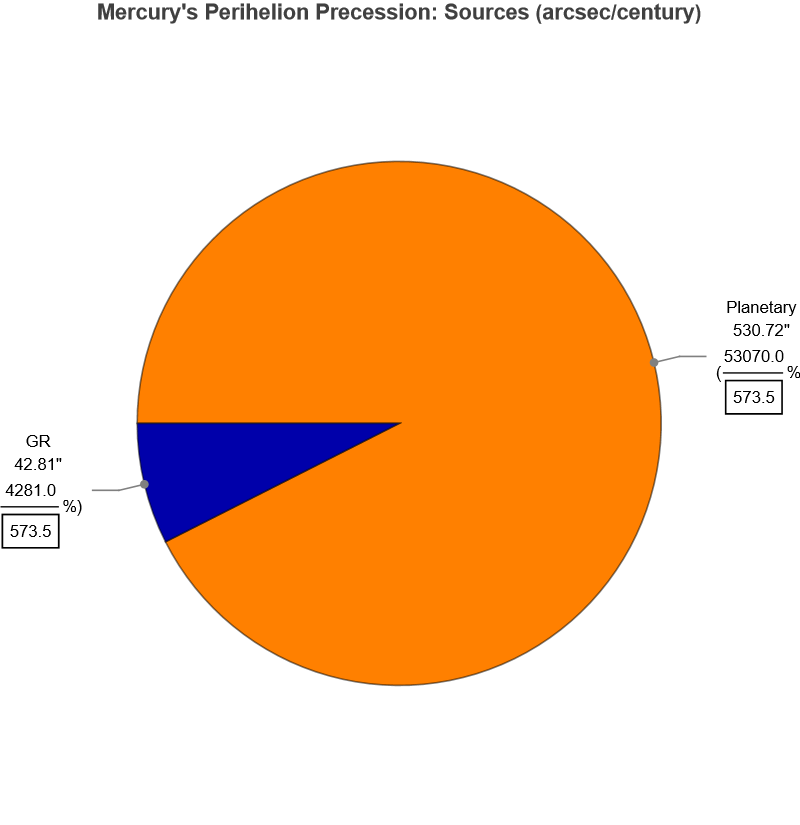

In [683]:
(* Pie chart: NRel vs GR contribution *)
PLOTPie = PieChart[
  {PerihelionPrecNRel, PerihelionPrecGR},
  ChartLabels -> Placed[
    {Row[{"Planetary\n", NumberForm[PerihelionPrecNRel,{5,2}], "\"\n(", 
          NumberForm[100 PerihelionPrecNRel/PerihelionPrecTot,{4,1}], "%)"}],
     Row[{"GR\n", NumberForm[PerihelionPrecGR,{4,2}], "\"\n(",
          NumberForm[100 PerihelionPrecGR/PerihelionPrecTot,{4,1}], "%)"}]},
    "RadialCallout"],
  ChartStyle -> {Orange, Darker[Blue]},
  PlotLabel -> Style["Mercury's Perihelion Precession: Sources (arcsec/century)", Bold, 13],
  ImageSize -> 480];
PLOTPie
Export["D:\\AE-442\\Project1\\figures\\bonus-precession-pie.pdf", PLOTPie];
Print["Exported: figures/bonus_precession_pie.pdf"]

### GR precession sensitivity: varies with eccentricity

Exported: figures/bonus_GR_vs_eccentricity.pdf


-Graphics-
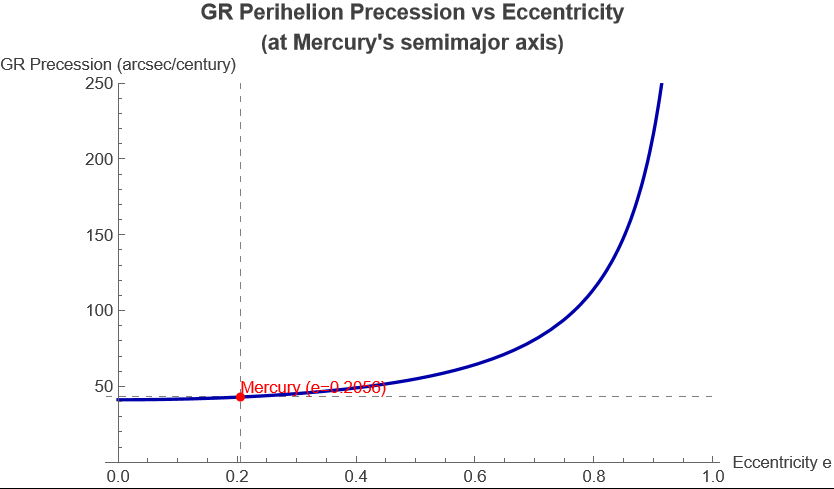

In [692]:
(* How does GR precession per century change with eccentricity for Mercury's semimajor axis? *)
aSMA = SemiMajor[69.82 10^9, 46 10^9];
nRevCent = (100 SiderealYr)/PeriodRev[69.82 10^9, 46 10^9];
GRvse[e_] := 6 Pi kSun / (cLight^2 aSMA (1 - e^2)) * (180/Pi) * 3600 * nRevCent;

PLOTGRvsE = Plot[GRvse[e], {e, 0, 0.99},
  PlotStyle -> Darker[Blue],
  PlotRange -> {0, 250},
  GridLines -> {{0.2056}, {43}},
  GridLinesStyle -> Directive[Dashed, Gray],
  AxesLabel -> {"Eccentricity e", "GR Precession (arcsec/century)"},
  PlotLabel -> Style["GR Perihelion Precession vs Eccentricity\n(at Mercury's semimajor axis)", Bold, 13],
  Epilog -> {Red, PointSize[0.015],
    Point[{0.2056, GRvse[0.2056]}],
    Text[Style["Mercury (e=0.2056)", Red, 10], {0.2056, GRvse[0.2056]}, {-1, -1}]},
  ImageSize -> 500];
PLOTGRvsE
Export["D:\\AE-442\\Project1\\figures\\bonus-GR-vs-eccentricity.pdf", PLOTGRvsE];
Print["Exported: figures/bonus_GR_vs_eccentricity.pdf"]

### Summary comparison table (this work vs literature)

Exported: figures/bonus_comparison_table.pdf


Source                              Precession (arcsec/century)   Notes

Planetary perturb. (this work)      530.722                       Numerical integration

Planetary perturb. (Price & Rush)   531.9                         Analytical, 1979

GR contribution (this work)         42.8103                       Einstein 1915 formula

GR contribution (analytical)        42.98                         Exact formula

Total (this work)                   Framed[573.532]               Sum

Observed (Price & Bush 1979)        574.8                         Observational
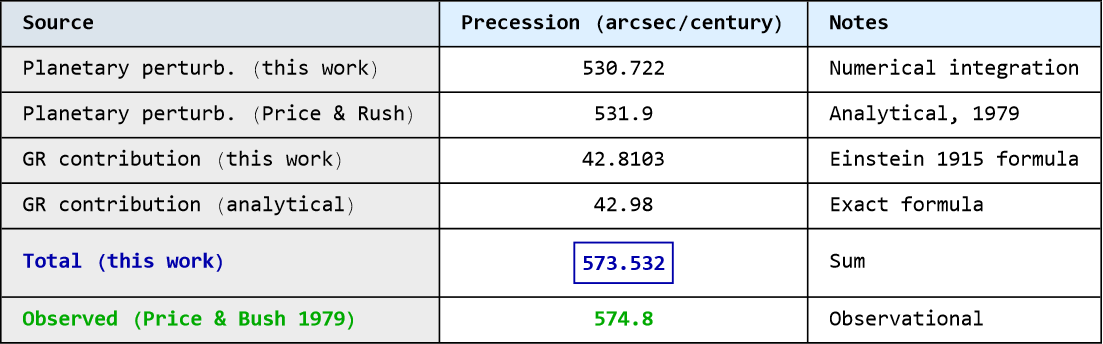

In [704]:
(* Final formatted comparison grid *)
compData = {
  {Style["Source", Bold], Style["Precession (arcsec/century)", Bold], Style["Notes", Bold]},
  {"Planetary perturb. (this work)", PerihelionPrecNRel, "Numerical integration"},
  {"Planetary perturb. (Price & Rush)", 531.9, "Analytical, 1979"},
  {"GR contribution (this work)", PerihelionPrecGR, "Einstein 1915 formula"},
  {"GR contribution (analytical)", 42.98, "Exact formula"},
  {Style["Total (this work)", Bold, Darker[Blue]], Style[PerihelionPrecTot, Bold, Darker[Blue]], "Sum"},
  {Style["Observed (Price & Bush 1979)", Bold, Darker[Green]], Style[574.8, Bold, Darker[Green]], "Observational"}
};

PLOTCompTable = Grid[compData, Frame -> All,
  Background -> {{LightGray, None, None}, {LightBlue, {White}}},
  Alignment -> {{Left, Center, Left}},
  Spacings -> {2, 1.2}];
PLOTCompTable
Export["D:\\AE-442\\Project1\\figures\\bonus_comparison_table.pdf", PLOTCompTable];
Print["Exported: figures/bonus_comparison_table.pdf"]

## <a class="anchor" id="References"></a> References 

[Back to Table of Contents](#Table_of_Contents) 


R. R. Bate, D. D. Mueller, and J. E. White, *Fundamentals of Astrodynamics* (Dover Publications, New York, 1971). <br>
https://archive.org/details/BateMuellerAndWhiteFundamentalsOfAstrodynamics/


A. Biswas and K. R. S. Mani, "Relativistic Perihelion Precession of Orbits of Venus and the Earth," *Central European Journal of Physics*, **6**, 754-758 (2008).  <br>
https://arxiv.org/ftp/arxiv/papers/0802/0802.0176.pdf

B. Davies, "Elementary theory of perihelion precession," *Am. J. Phys.*, **51**, 909-911 (1983). 

A. Einstein, "Explanation of the Perihelion Motion of Mercury from General Relativity Theory," Königlich Preußische Akademie der Wissenschaften (Berlin). Sitzungsberichte, 831-839 (1915). Translated by Anatoli Andrei Vankov. <br>
https://www.researchgate.net/publication/228923053_Einstein%27s_PaperExplanation_of_the_Perihelion_Motion_of_Mercury_from_General_Relativity_Theory

H. Goldstein, C. Poole, and J. Safko, *Classical Mechanics* (Addison-Wesley, San Francisco, 2012). <br>
https://archive.org/details/HerbertGoldsteinCharlesPooleJohnSafkoClassicalMechanics3rdEd


C. Kittel, W. D. Knight, M. A. Ruderman, *Berkeley Physics Course Vol. 1 (Mechanics)* (McGraw Hill Book Company, New York, 1973). <br>
https://archive.org/details/BerkeleyPhysicsCourse


F. R. Moulton, *An Introduction to Celestial Mechanics* (The MacMillan Company, London, 1914). <br>
https://archive.org/details/introcelestial00moulrich 

M. P. Price and W. F. Rush, "Nonrelativistic contribution to Mercury’s perihelion precession," *Am. J. Phys.*, **47**, 531-534 (1979).


B. Shahid-Saless and D. K. Yeomans, "Relativistic effects on the motion of asteroids and comets," *Astron. J.*, **107**, 1885-1889 (1994). <br>
https://articles.adsabs.harvard.edu/cgi-bin/nph-iarticle_query?1994AJ....107.1885S&defaultprint=YES&filetype=.pdf


A. Sommerfeld, *Atomic Structure and Spectral Lines* (Methuen & Co. Ltd., London, 1934), 3rd Ed. <br>
https://archive.org/details/0244-pdf-atomic-structure-and-spectral-lines-arnold-sommerfeld-2 

S. Weinberg, *Gravitation and Cosmology* (John Wiley & Sons, Inc., New York, 1972). <br>
https://archive.org/details/WeinbergS.GravitationAndCosmology..PrinciplesAndApplicationsOfTheGeneralTheoryOf/mode/2up

## <a class="anchor" id="ChangeLog"></a> ChangeLog

[Back to Table of Contents](#Table_of_Contents) 

### v. 1.0.0

2022-12-11&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* File created.

### v. 1.0.1

2026-04-27&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* I/O file locations and class name updated.

### v. 1.0.2 (student version)

2026-05-13&nbsp;&nbsp; Kaoutar Ammara  

* Adapted for personal submission: header updated, figures export cells added.
* Created `figures/` subfolder for PDF exports.
* Added visualizations: planet contribution bar chart, precession breakdown pie chart, comparison table, GR sensitivity plot.


<div class="alert alert-block alert-info">
<span style='color:black'>  "Precession of the perihelion" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

 <div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 